# Tire Pressure Slow Leakage Detection at Fleet Scale Demostration 

CIKM 2026 Replication Artifact

Core Algorithm Pipeline: From Baseline Fleet Modeling to Out-of-Sample Production Deployment


Academic Replication & Benchmark Datasets

Due to cloud-native architectural boundaries and commercial data privacy guidelines regarding fleet geospatial telemetry (e.g., GPS height vectors vulnerable to route reverse-engineering), this public replication pipeline initiates directly from the fully normalized and cleaned dataset stage.

We provide a structured, two-part benchmark framework consisting of 25 representative vehicles each to rigorously validate our experimental claims:

1_fleet_modeling_demo.parquet (Fleet Modeling Phase): Contains complete historical records of 25 vehicles to establish baseline tire behavior, perform robust features engineering, and cross-validate across cross-tire position topologies.

2_out_of_sample_demo.parquet (Deployment & Testing Phase): Tracks an independent forward-looking timeline of completely different 25 vehicles  to simulate a real-world production roll-out and evaluate anti-leak generalization performance.




# Read Library

In [71]:

# 1. Machine Learning & Spark ML (SynapseML)

from synapse.ml.isolationforest import IsolationForest, IsolationForestModel
from pyspark.ml.feature import VectorAssembler, StandardScaler, Bucketizer
from pyspark.ml.linalg import Vectors, VectorUDT
from pyspark.ml import Pipeline, PipelineModel
from pyspark.ml.classification import GBTClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.mllib.evaluation import BinaryClassificationMetrics
from pyspark.ml.functions import vector_to_array


# 2. PySpark SQL & Window Functions

from pyspark.sql import Window
from pyspark.sql.types import *
from pyspark.sql.functions import *
import pyspark.sql.functions as F


# 3. Math, Scientific Computing & Statistics

import numpy as np
import math
from scipy import stats
import itertools
import builtins


# 4. Dates & Time Management

import datetime
from datetime import date


# 5. Data Visualization & Analytics (Pandas/Seaborn/Plotly)

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots


import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
import textwrap

StatementMeta(spkaplarge, 37, 72, Finished, Available, Finished, False)

# Load Data
- Load normalized TPMS (pressure) data

In [2]:
# Access ADLS 
token_library = spark._jvm.com.microsoft.azure.synapse.tokenlibrary.TokenLibrary
encur_account_name = token_library.getFullConnectionString("DataLakeEnCur").split("//")[1].split(".")[0]

# Define file paths for various datasets
workbench_account_name = "weukfpkapprdworkst001"
workbench_container_name = 'kfpworkbench'


# Development Data Set Demo
# Generate relative path 
tpms_development = 'TPMS/1_fleet_modeling_demo/'
# Generate absolute path
tpms = f'abfss://{workbench_container_name}@{workbench_account_name}.dfs.core.windows.net/{tpms_development}'
tpms_data = spark.read.format("parquet").load(tpms)

# Prediction Data Set Demo

tpms_prediction = 'TPMS/2_out_of_sample_demo/'
# Generate full path for datasets
demo_data_path = f'abfss://{workbench_container_name}@{workbench_account_name}.dfs.core.windows.net/{tpms_prediction}' # full path can be found by dataset
prediction_data = spark.read.format("parquet").load(demo_data_path)

StatementMeta(spkaplarge, 37, 3, Finished, Available, Finished, False)

# Dataframe Processing

## 1. Unpivot Data

In [4]:
# unpivot

tpms_data_long = tpms_data.select(
    "mongoID",
    "timestamp",
    "date",
    expr("""
        stack(
            8,
            'pressure_17', pressure_17,
            'pressure_19', pressure_19,
            'pressure_27', pressure_27,
            'pressure_29', pressure_29,
            'pressure_37', pressure_37,
            'pressure_39', pressure_39,
            'pressure_16', pressure_16,
            'pressure_1a', pressure_1a
        ) AS (Position, pressure)
    """)
)

# Rename Column 
tpms_data_long = tpms_data_long.withColumn(
    "Position",
    regexp_extract("Position", r"pressure_([0-9a-z]+)", 1)
)

# Re-order Column
tpms_data_long = tpms_data_long.select(
    "mongoID",
    "Position",
    "date",
    "timestamp",
    "pressure"
)

# Order whole sequence
tpms_wrangled = tpms_data_long.orderBy('mongoID','Position','date','timestamp')


StatementMeta(spkaplarge, 37, 5, Finished, Available, Finished, False)

## 2. Daily Aggregation

In [5]:
# daily aggregation
tpms_daily =(tpms_wrangled.groupBy('mongoID','Position','date')
                            .agg(round(avg('pressure'),2).alias('pressure'))
).orderBy('mongoID','Position','date')

# remove blank days
tpms_daily_non_nan = tpms_daily.filter(col('pressure').isNotNull())


StatementMeta(spkaplarge, 37, 6, Finished, Available, Finished, False)

## 3. Moving Average to eliminate punctual error


In [6]:
# define windows
w_prev = Window.partitionBy("mongoID", "Position").orderBy("date").rowsBetween(-3, -1)
w_next = Window.partitionBy("mongoID", "Position").orderBy("date").rowsBetween(1, 3)

# avg pressure 3 days before + 3 days after
tpms_with_ma = (
    tpms_daily_non_nan
    .withColumn("mean_prev3", avg("pressure").over(w_prev))
    .withColumn("mean_next3", avg("pressure").over(w_next))
)

# condition:
condition1 = (abs(col("mean_prev3") - col("pressure")) >= 0.3)
condition2 = (abs(col("mean_next3") - col("pressure")) >= 0.3)
condition3 = (abs(col("mean_next3") - col("mean_prev3")) <= 0.3)

# tag outlier
tpms_flagged = tpms_with_ma.withColumn(
    "is_outlier_day",
    when(condition1 & condition2 & condition3, lit(1)).otherwise(lit(0))
)

# keep cleaned data (remove outlier day)
tpms_cleaned = (
    tpms_flagged
    .filter(col("is_outlier_day") == 0)
    .select("mongoID", "Position", "date", "pressure")
    .orderBy("mongoID", "Position", "date")
)


StatementMeta(spkaplarge, 37, 7, Finished, Available, Finished, False)

## 4. Cut Session
    # Domain-dependent thresholds: +0.3 bar for over-inflation caused by driver, -0.3 bar for deflation.
    # Note: These thresholds are statistically derived specifically for trucks and trailers.
    # For passenger vehicles (Tires typically 2.0-3.0 bar), thresholds must be scaled down accordingly.

In [7]:
# Cut time serie data into sessions, seperate sessions by inflation

# filter non rows
session_ready = tpms_cleaned.filter(col("pressure").isNotNull())

# set window
w = Window.partitionBy("mongoID",'Position').orderBy("date")

# Step 1 daily deltaP with skipping NaN
# fetch last non NaN row

df_with_prev = session_ready.withColumn(
    'pressure_prev',
    lag('pressure',1).over(w)
)

# Step 2 daily deltaP
df_diff = df_with_prev.withColumn(
    'deltaP',
    round(col('pressure') - col('pressure_prev'), 2)
)
df_diff = df_diff.fillna(0, subset=['deltaP'])

# Step 3 flag inflation and deflation
# define inflation and deflation threshold as +/- 0.3
# here is technically very challenging. IF shreshold too small, the normal curve (with noise) tend to be cut into tiny session. If shreshold too large, many of the deflation can not be seperated previously

THRESHOLD_INFLATION = 0.3
THRESHOLD_DEFLATION = -0.3 

cond_inflation = col('deltaP') >= THRESHOLD_INFLATION
cond_deflation = col('deltaP') <= THRESHOLD_DEFLATION


df_flagged = df_diff.withColumn("is_change", 
    when(cond_inflation | cond_deflation, lit(1)).otherwise(lit(0))
)

# Step 4 count session
# within each mongoID, calculate cumulative inflation times. e.g. first inflation session = 1, for second time +1
df_session =  df_flagged.withColumn('session_idx', sum(col('is_change')).over(w))


# Step 5 set session and transform into string name
df_session = df_session.withColumn(
    "sample_id",
    concat_ws("_", col("mongoID"), col("Position"), lit("sess"), col("session_idx"))
)

# Step 6 final output result
df_final = df_session.select('sample_id','mongoID','Position','date','pressure')


# !do not orderby now, order in next step after date shuffle


"""
# following code will only used to control the result
# control result in visual
plt = px.scatter(df_final.filter(col('mongoID')=='5f4d2843e4b06901dcbb338b').filter(col('Position')=='37').filter(col('session')=='session5').toPandas(), x='date',y='pressure')
plt.show()

# control result in df
display(df_final.filter(col('mongoID')=='5f4d2843e4b06901dcbb338b').filter(col('Position')=='37'))

"""

StatementMeta(spkaplarge, 37, 8, Finished, Available, Finished, False)

"\n# following code will only used to control the result\n# control result in visual\nplt = px.scatter(df_final.filter(col('mongoID')=='5f4d2843e4b06901dcbb338b').filter(col('Position')=='37').filter(col('session')=='session5').toPandas(), x='date',y='pressure')\nplt.show()\n\n# control result in df\ndisplay(df_final.filter(col('mongoID')=='5f4d2843e4b06901dcbb338b').filter(col('Position')=='37'))\n\n"

# Feature Pre-Processing

## Length check: Control session length (duration)

In [8]:
# all session SHOULD >30 days (Physical day)
# This is because, the slow tire leakage should only be measures if the time discrepancy is more than 30 days

# Step 6 Session length -> remove all session < 30 days, due to Y Label
w_session = Window.partitionBy('sample_id')
df_with_duration = df_final.withColumn("start_date", min('date').over(w_session))\
                            .withColumn('end_date', max('date').over(w_session))\
                            .withColumn('duration_days', datediff(col('end_date'),col('start_date')))
                            

# Step 7 filter according to days
# remove all sessions with less than 30 days
min_duration = 30
df_final_filtered = df_with_duration.filter(col('duration_days') >= min_duration)

StatementMeta(spkaplarge, 37, 9, Finished, Available, Finished, False)

## Control days within session

In [9]:

w_count = Window.partitionBy('sample_id')
df_density_check = df_final_filtered.withColumn("data_count", count("pressure").over(w_count))
MIN_DATA_POINTS = 30 # 30 data points ensure at least 30 days, in most case even  > 30 days
df_ready_for_labeling = df_density_check.filter(col("data_count") >= MIN_DATA_POINTS)
df_ready_for_labeling.cache()



StatementMeta(spkaplarge, 37, 10, Finished, Available, Finished, False)

DataFrame[sample_id: string, mongoID: string, Position: string, date: date, pressure: double, start_date: date, end_date: date, duration_days: int, data_count: bigint]

## Generate Features

### Y Label (Ground Truth/ True Positive) Maximize Label Purity
- ! VERY Important ! Use 30 data points not 30 days to calculate slope. We have following strong Reasons to doing so:

- 1. The definition oriented on tire workshop or domai experts. -> 30 d, but in our data, some times 1 month has less than 30 data points.
- 2. we don't impute data, so left blank days. Because TPMS data should be every day different, every data point different. we can not imput with mean, prefer leave them blank. The rolling window in next section based on data points instead of physical days. So it is important to use same logic - data points to check leakage.
- 3. we focus mainly on "current" , thus if last month dropped but this month no more (tire self repaired somehow), we regart the case as no leakage. so "current" means this month, althrough 50% data is in last month, we will discard this pollution data.
   


### Metric Sensitivity Test

    Y Label Detection Logic:
    last 30 data Points 
    - 1. For each sample_id, order descending, get rn_last30 as row number, rn=1 is the last row.
    - 2. Whole session  -> Theil-Sen slope + Regression OLS (R2)
    - 3. Cut last 30 none nan data point: y_tail = y[-30:] -> tail_len = 30
    - 4. X axis is date -> x_days = (date-start).dt.days
    - 5. Calculate the ols drop slope for last 30 data points within the periode (maybe 1 month, maybe more)
    - 6. Calculate std of tail data np.std(residuals) -> to ensure the swing of data not goes up and down too excessive
    - 7. Count drop of each 2 points in tail, and the proportion. drop_count / len -> to ensure the trend is large like "continuous goes down" not turbulance
    - 8. All conditions should be met
    - 9. For "Positive" label, keep only last 30 data points for training rn_last30 <=30 -> ensure the rest of session data are free of noise
    - 10. For "Negative" label, keep all.


In [10]:
import warnings

warnings.simplefilter(action='ignore', category=FutureWarning)


# 1. Data Preparation (Add Row Number for Point-Based Logic)

# We need row numbers to identify the "Last 30 Data Points"
# This aligns with the Rolling Window logic downstream.
w_last30pts = Window.partitionBy("sample_id").orderBy(col("date").desc())

# Add a rank column: 1 is the last point, 2 is the second last...
df_ready_processed = df_ready_for_labeling.withColumn("rn_last30", row_number().over(w_last30pts))



# 2. Define Output Schema

output_schema = StructType([
    StructField("sample_id", StringType(), True),
    StructField("duration_days", IntegerType(), True), 
    StructField("data_count", IntegerType(), True),
    
    # --- The 5 Core Tail Metrics ---
    # 1. OLS Slope: standard regression (Sensitive)
    StructField("slope_tail_ols", DoubleType(), True),      
    
    # 2. Theil-Sen Slope: robust median regression (Robust to outliers) 
    StructField("slope_tail_theil", DoubleType(), True),    # T-S
    
    # 3. R-Squared: Goodness of fit for the tail
    StructField("tail_r2", DoubleType(), True),             
    
    # 4. Residual Std: Linearity check
    StructField("tail_residual_std", DoubleType(), True),   
    
    # 5. Drop Proportion: Monotonicity check
    StructField("tail_drop_prop", DoubleType(), True),      

    # 6. P Value: Statistical Significance [Fixed syntax error here]
    StructField("slope_p_value", DoubleType(), True),

    # --- Metadata ---
    StructField("intercept_tail", DoubleType(), True),
    StructField("tail_days_span", IntegerType(), True)
])


# 3. Define Pandas UDF (Logic: Last 30 Points, Days for Slope)

@pandas_udf(output_schema, PandasUDFType.GROUPED_MAP)
def calculate_trend_metrics(pdf):
    if pdf.empty: return pd.DataFrame()

    # [Fixed Indentation below]
    # 3.1. Basic Info
    sample_id = pdf['sample_id'].iloc[0]
    duration = pdf['duration_days'].iloc[0]  
    count_total = pdf['data_count'].iloc[0]
    
    # 3.2. Prepare Data
    pdf = pdf.sort_values('date') 
    session_start_date = pdf['date'].iloc[0]
    
    # X axis: Physical Days (Unit consistency)
    x_days_all = (pdf['date'] - session_start_date).dt.days.values
    y_all = pdf['pressure'].values

    # 3.3. Focus on TAIL (Last 30 Data Points)
    tail_len = 30
    
    if len(y_all) >= tail_len:
        y_tail = y_all[-tail_len:]
        x_tail = x_days_all[-tail_len:]
    else:
        y_tail = y_all
        x_tail = x_days_all
    
    tail_pts_count = len(y_tail)
    tail_days_span = int(x_tail[-1] - x_tail[0]) if tail_pts_count > 0 else 0

    # 3.4. Calculate 5 Metrics
    if tail_pts_count >= 2:
        # Metric 1 & 3: OLS Slope & R2
        slope_ols, intercept_t, r_val_t, p_val_t, std_err_t = stats.linregress(x_tail, y_tail)
        tail_r2 = r_val_t**2
        
        # Metric 2: Theil-Sen Slope (Robust)
        # return: [slope, intercept, low_slope, high_slope]
        try:
            res_ts = stats.theilslopes(y_tail, x_tail, 0.95)
            slope_theil = res_ts[0]
        except:
            slope_theil = 0.0

        # Metric 4: Residual Std (Based on OLS line usually)
        y_pred_tail = slope_ols * x_tail + intercept_t
        residuals = y_tail - y_pred_tail
        tail_residual_std = np.std(residuals, ddof=1)
        
        # Metric 5: Drop Proportion
        diffs = np.diff(y_tail)
        if len(diffs) > 0:
            tail_drop_prop = np.sum(diffs < 0) / len(diffs)
        else:
            tail_drop_prop = 0.0
            
    else:
        slope_ols = 0.0; slope_theil = 0.0; tail_r2 = 0.0
        p_val_t = 1.0 # Default Not Significant
        tail_residual_std = 0.0; tail_drop_prop = 0.0; intercept_t = 0.0

    return pd.DataFrame([{
        "sample_id": sample_id,
        "duration_days": duration,
        "data_count": count_total,
        "slope_tail_ols": slope_ols,
        "slope_tail_theil": slope_theil,
        "tail_r2": tail_r2,
        "slope_p_value" : p_val_t,
        "tail_residual_std": tail_residual_std,
        "tail_drop_prop": tail_drop_prop,
        "intercept_tail": intercept_t,
        "tail_days_span": tail_days_span 
    }])


# 4. Call UDF 

df_metrics = df_ready_processed.groupby("sample_id").apply(calculate_trend_metrics)



# 5. Metrics Sensitivity Test Grid Search 

print(f"Total metrics rows: {df_metrics.count()}")

# Define metric grid with 5 parameters
scenarios = [
    {
        "name": "V1_Strict (Benchmark)", 
        "slope_ols": -0.2 / 30.0,   # -0.0067
        "slope_ts":  -0.2 / 30.0,   # TS must also be steep
        "r2":        0.60,          # High R2 required (Strong linearity)
        "resid":     0.15,          # Very tight
        "drop":      0.60,
        "p_value":   0.05
    }
]

# Print Header
print(f"{'Scenario':<25} | {'OLS Thr':<10} | {'TS Thr':<10} | {'R2 Min':<8} | {'Resid Max':<10} | {'Drop Min':<8} | {'P value':<10} | {'Count':<6}")
print("-" * 105)

for s in scenarios:
    slope_ols_thr = s["slope_ols"]
    slope_ts_thr = s["slope_ts"]
    r2_thr = s["r2"]
    resid_thr = s["resid"]
    drop_thr = s["drop"]
    p_value = s['p_value']
    
    # Count result
    count = df_metrics.filter(
        # 1. OLS Slope Check
        (col("slope_tail_ols") < slope_ols_thr) & 
        
        # 2. Theil-Sen Slope Check (Double Confirmation)
        (col("slope_tail_theil") < slope_ts_thr) &
        
        # 3. R2 Check (Quality of trend)
        (col("tail_r2") >= r2_thr) &
        
        # 4. Linearity Check
        (col("tail_residual_std") <= resid_thr) & 
        
        # 5. Monotonicity Check
        (col("tail_drop_prop") >= drop_thr) & 

        # 6. Statistical Significance Check [Fixed column name]
        (col("slope_p_value") <= p_value) &
        
        # Safety check
        (col("slope_tail_ols") != 0.0) 
    ).count()
    
    print(f"{s['name']:<25} | {slope_ols_thr:.5f}    | {slope_ts_thr:.5f}    | {r2_thr:<8} | {resid_thr:<10} | {drop_thr:<8} | {p_value:<8} | {count:<6}")

StatementMeta(spkaplarge, 37, 11, Finished, Available, Finished, False)

/opt/spark/python/lib/pyspark.zip/pyspark/sql/pandas/group_ops.py:98: UserWarning: It is preferred to use 'applyInPandas' over this API. This API will be deprecated in the future releases. See SPARK-28264 for more details.


Total metrics rows: 172
Scenario                  | OLS Thr    | TS Thr     | R2 Min   | Resid Max  | Drop Min | P value    | Count 
---------------------------------------------------------------------------------------------------------
V1_Strict (Benchmark)     | -0.00667    | -0.00667    | 0.6      | 0.15       | 0.6      | 0.05     | 9     


#### Attatch Y Label

In [11]:

# 6. Final Label Definition (Strategy: V1 Strict Benchmark)


# --- V1 Strict Thresholds (5 Parameters) ---

# a. OLS Slope Check: Standard regression sensitivity
# -0.2 bar / 30 days = -0.006666...
LEAK_SLOPE_OLS_THRESHOLD = -0.2 / 30.0   

# b. Theil-Sen Slope Check: Robustness check against outliers
LEAK_SLOPE_TS_THRESHOLD  = -0.2 / 30.0   

# c. R-Squared Check: Strong linearity required
R2_THRESHOLD             = 0.60          

# d. Residual Std Check: Very tight fit (low noise)
RESIDUAL_STD_THRESHOLD   = 0.15          

# e. Monotonicity Check: Strict drop consistency
DROP_PROP_THRESHOLD      = 0.60          

# f. Statistical Significance Check
P_VALUE_THRESHOLD        = 0.05

df_labeled_metrics = df_metrics.withColumn(
    "dataset_type",
    when(
        # All 5 conditions must be met (The "AND" Gate)
        (col("slope_tail_ols") < LEAK_SLOPE_OLS_THRESHOLD) &      # Param 1
        (col("slope_tail_theil") < LEAK_SLOPE_TS_THRESHOLD) &     # Param 2
        (col("tail_r2") >= R2_THRESHOLD) &                        # Param 3
        (col("tail_residual_std") <= RESIDUAL_STD_THRESHOLD) &    # Param 4
        (col("tail_drop_prop") >= DROP_PROP_THRESHOLD) &          # Param 5
        (col("slope_p_value") <= P_VALUE_THRESHOLD) &             # Param 6
        (col("slope_tail_ols") != 0.0), # Safety check
        lit('Positive')
    )
    .otherwise(lit('Negative'))
)



# 7. Data Filtering Strategy (Discard History for Positives)

# Join Label back to data
df_final_dataset_with_label = df_ready_processed.join(
    df_labeled_metrics.select("sample_id", "dataset_type", "slope_tail_ols", "intercept_tail"), 
    on="sample_id", 
    how="inner"
)

# Filter Logic:
# Positive Label: Keep ONLY the last 30 Data Points (Rows). 
#                 History (rn_last30 > 30) is implicitly DISCARDED.
# Negative Label: Keep Everything.

df_final_clean = df_final_dataset_with_label.filter(
    (col("dataset_type") == 'Negative') | 
    (
        (col("dataset_type") == 'Positive') & 
        (col("rn_last30") <= 30)  # Correct: Keeps only tail (1-30), discards history (31+)
    )
)


# 8. Output Verification

print(f"--- Final Label Distribution (Strategy V1 Strict) ---")
print(f"Params: OLS<{LEAK_SLOPE_OLS_THRESHOLD:.5f} | TS<{LEAK_SLOPE_TS_THRESHOLD:.5f} | R2>={R2_THRESHOLD} | Resid<={RESIDUAL_STD_THRESHOLD} | Drop>={DROP_PROP_THRESHOLD} | PVal<={P_VALUE_THRESHOLD}")

df_labeled_metrics.groupBy("dataset_type").count().show()

print("--- Data Check (Rows per Sample) ---")
# Check max data count in positive samples (Should be exactly 30 or less)
df_final_clean.filter(col("dataset_type") == "Positive") \
    .groupBy("sample_id").count() \
    .agg({"count": "max"}).show()

StatementMeta(spkaplarge, 37, 12, Finished, Available, Finished, False)

--- Final Label Distribution (Strategy V1 Strict) ---
Params: OLS<-0.00667 | TS<-0.00667 | R2>=0.6 | Resid<=0.15 | Drop>=0.6 | PVal<=0.05
+------------+-----+
|dataset_type|count|
+------------+-----+
|    Negative|  163|
|    Positive|    9|
+------------+-----+

--- Data Check (Rows per Sample) ---
+----------+
|max(count)|
+----------+
|        30|
+----------+



#### Control Total Result of V1 Label Strategy

In [12]:
from pyspark.sql.functions import col, count as spark_count, max as spark_max
print("=== STARTING DATA INTEGRITY CHECK ===")


# 1. Check positive session row length

print("\n--- [Check 1] Positive Samples: Length Constraint ---")

df_pos_check = df_final_clean.filter(col("dataset_type") == 'Positive')
pos_count = df_pos_check.select("sample_id").distinct().count()
print(f"Total Positive Samples identified: {pos_count}")

df_pos_stats = df_pos_check.groupBy("sample_id").agg(
    spark_count("*").alias("row_count"),
    spark_max("rn_last30").alias("max_rn")
)


violations = df_pos_stats.filter((col("row_count") > 30) | (col("max_rn") > 30))

if violations.count() == 0:
    print("PASS: All Positive samples have <= 30 data points.")
    print("PASS: All history data (rn > 30) for Positive samples has been DISCARDED.")
    
    # result
    print("Positive Sample Length Distribution:")
    df_pos_stats.groupBy("row_count").agg(spark_count("*").alias("cnt")).show()
else:
    print("FAIL: Found Positive samples with > 30 points! Check logic.")
    violations.show()



# 2. check Negative sample (Target: Should have history > 30)

print("\n--- [Check 2] Negative Samples: History Retention ---")

df_neg_check = df_final_clean.filter(col("dataset_type") == 'Negative')

# Negative sample length (max)
df_neg_stats = df_neg_check.groupBy("sample_id").agg(
    spark_max("rn_last30").alias("max_rn")
)

long_history_count = df_neg_stats.filter(col("max_rn") > 30).count()

if long_history_count > 0:
    print(f"PASS: Found {long_history_count} Negative samples with full history (points > 30).")
    print("Sample lengths for Negatives (Top 5):")
    df_neg_stats.orderBy(col("max_rn").desc()).show(5)
else:
    print("WARNING: No Negative sample has > 30 points. Is your dataset purely short sessions?")

print("\n=== CHECK COMPLETE ===")


print(f"Joined Data Count: {df_final_clean.count()}")



# 3. Position vs Label Distribution 

# 1. Pivot table (Rows: Position, Cols: Negative, Positive)
df_pos_stats = df_final_clean.groupBy("Position") \
    .pivot("dataset_type") \
    .count() \
    .na.fill(0)  

# 2. Sort by Position 
df_pos_stats = df_pos_stats.orderBy(col("Position").cast("int"))

print("--- Distribution by Position (Pivot Table) ---")

df_pos_stats.show(100)

# 3. Check for Tire：Position 39 (Validation data should have positive samples)

print("--- Check Candidate for Validation (Position 39) ---")
target_pos_check = df_pos_stats.filter(col("Position") == 39)

if target_pos_check.count() > 0:
    target_pos_check.show()
    
 
    row = target_pos_check.collect()[0]
    pos_count = row['Positive'] if 'Positive' in row else 0
    
    if pos_count > 0:
        print(f"Position 39 is GOOD for Validation. It has {pos_count} Positive samples.")
    else:
        print(f"Position 39 is BAD for Validation. It has 0 Positive samples.")
        print("If you use it, you cannot calculate Recall.")
else:
    print("Position 39 does not exist in the dataset.")




StatementMeta(spkaplarge, 37, 13, Finished, Available, Finished, False)

=== STARTING DATA INTEGRITY CHECK ===

--- [Check 1] Positive Samples: Length Constraint ---
Total Positive Samples identified: 9
PASS: All Positive samples have <= 30 data points.
PASS: All history data (rn > 30) for Positive samples has been DISCARDED.
Positive Sample Length Distribution:
+---------+---+
|row_count|cnt|
+---------+---+
|       30|  9|
+---------+---+


--- [Check 2] Negative Samples: History Retention ---
PASS: Found 158 Negative samples with full history (points > 30).
Sample lengths for Negatives (Top 5):
+--------------------+------+
|           sample_id|max_rn|
+--------------------+------+
|63918869e4b0548d7...|   455|
|64218239e4b0611c9...|   454|
|64218239e4b0611c9...|   453|
|63918869e4b0548d7...|   453|
|64218239e4b0611c9...|   449|
+--------------------+------+
only showing top 5 rows


=== CHECK COMPLETE ===
Joined Data Count: 26144
--- Distribution by Position (Pivot Table) ---
+--------+--------+--------+
|Position|Negative|Positive|
+--------+--------+

##### Dateset Type Positive


StatementMeta(spkaplarge, 37, 14, Finished, Available, Finished, False)

Plotting ALL 9 samples identified by V1 Strategy...


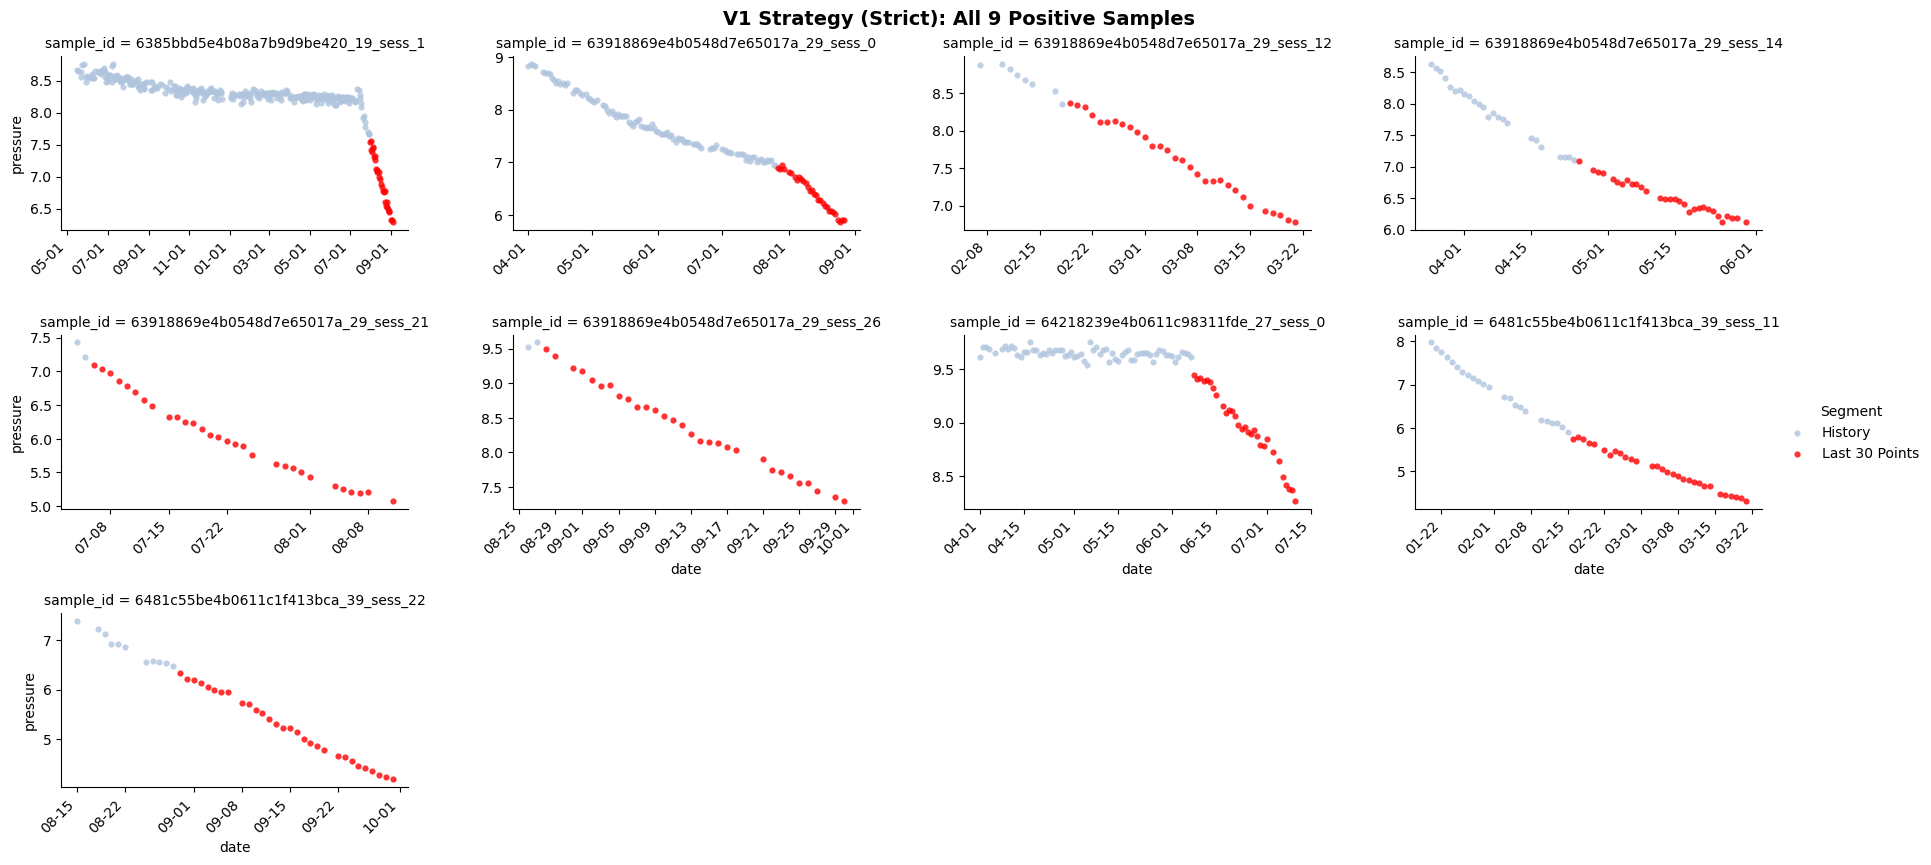

In [13]:
# Suppress warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# ==========================================
# 1. Fetch ALL Positive Sample IDs (V1 Strategy)
# ==========================================
# Get the full list of IDs identified as Positive
positive_samples = df_final_clean.filter(col("dataset_type") == 'Positive') \
    .select("sample_id").distinct().toPandas()['sample_id'].tolist()

count = len(positive_samples)
print(f"Plotting ALL {count} samples identified by V1 Strategy...")

# ==========================================
# 2. Fetch Full History Data
# ==========================================
# Query raw data to get the context (history)
pdf_plot = df_ready_for_labeling.filter(col("sample_id").isin(positive_samples)) \
    .select("sample_id", "date", "pressure").toPandas()

if not pdf_plot.empty:
    
    # Ensure datetime format
    pdf_plot['date'] = pd.to_datetime(pdf_plot['date'])
    
    # ==========================================
    # 3. Match Logic: "Last 30 Data Points"
    # ==========================================
    # Sort data to ensure correct ranking
    pdf_plot = pdf_plot.sort_values(['sample_id', 'date'])
    
    # Calculate Reverse Rank: 1 = Newest point, 30 = 30th from last
    pdf_plot['pts_rank'] = pdf_plot.groupby('sample_id')['date'].rank(method='first', ascending=False)
    
    # Define Segment
    def define_segment(row):
        if row['pts_rank'] <= 30:
            return 'Last 30 Points'
        return 'History'

    pdf_plot['segment'] = pdf_plot.apply(define_segment, axis=1)
    
    # ==========================================
    # 4. Visualization
    # ==========================================
    
    # Colors: Blue context, Red detection focus
    custom_colors = {'History': 'lightsteelblue', 'Last 30 Points': 'red'}
    
    # Create FacetGrid
    # Note: With ~70 samples, this will create a long scrolling image.
    g = sns.FacetGrid(pdf_plot, col="sample_id", col_wrap=4, 
                      sharex=False, sharey=False, height=2.8, aspect=1.6,
                      hue='segment', hue_order=['History', 'Last 30 Points'], palette=custom_colors)
    
    # Map Scatterplot
    # Optimized visual: s=20, linewidth=0 makes points look tighter and cleaner
    g.map(sns.scatterplot, "date", "pressure", alpha=0.8, s=20, linewidth=0)

    # Label Formatting
    for ax in g.axes.flat:
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
        ax.xaxis.set_major_locator(mdates.AutoDateLocator())
        plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

    # Add Legend
    g.add_legend(title="Segment")
    
    # ==========================================
    # 5. Layout Optimization (Tight Header)
    # ==========================================
    
    # top=0.91: Plots occupy 91% height
    # hspace=0.6: Vertical spacing to avoid x-axis label overlap
    plt.subplots_adjust(top=0.91, hspace=0.6, wspace=0.3)
    
    # Title just above the plots
    g.fig.suptitle(f'V1 Strategy (Strict): All {count} Positive Samples', y=0.995, fontsize=14, weight='bold')
    plt.subplots_adjust(top=0.94, hspace=0.6, wspace=0.3)
    plt.show()

else:
    print("No data found for the selected IDs.")

### Rolling Window

In [14]:

# 1. Ready for Sliding Window (Group & Sort)
df_grouped = df_final_clean.groupBy("sample_id", "dataset_type") \
    .agg(sort_array(collect_list(struct("date", "pressure"))).alias("time_series")) # sort date ascending


# 2. define sliding window UDF (Zero-Center normalization)
WINDOW_SIZE = 7 

result_schema = ArrayType(StructType([
    StructField("window_start_date", DateType(), False),
    StructField("features_norm", ArrayType(FloatType()), False), 
    StructField("features_raw", ArrayType(FloatType()), False)
]))

@udf(result_schema)
def create_windows(series_data):
    if len(series_data) < WINDOW_SIZE:
        return []
    
    windows = []
    for i in range(len(series_data) - WINDOW_SIZE + 1):
        segment = series_data[i : i + WINDOW_SIZE]
        
        start_date = segment[0]['date']
        # ensure float
        raw_pressures = [float(x['pressure']) for x in segment]
        
        # --- normalization ---
        # here is important. 
        # session A (Negative:[2.5,2.5,2.5])
        # session B (Nagative:[2.8,2.8,2.8])
        # IF will classifity them as different, because of the absolute value. we should let IF concentrate on the trend, not absolute value. so wie use
        # session A -->[0,0,0....]
        # session B -->[0,0,0]
        base_val = raw_pressures[0]
        norm_pressures = [p - base_val for p in raw_pressures]
        
        windows.append({
            "window_start_date": start_date,
            "features_norm": norm_pressures,
            "features_raw": raw_pressures
        })
    return windows


# 3. apply udf 
# posexplode get 2 columns: "pos" (index 0,1,2...) and "col" (structure)
df_windows = df_grouped.withColumn("windows", create_windows(col("time_series"))) \
    .select(
        "sample_id", 
        "dataset_type", 
        posexplode(col("windows")).alias("pos", "window_data") 
    ) \
    .select(
        # 1. get unique Window ID (e.g.: TireID_Sess1_Win0)
        concat_ws("_", col("sample_id"), col("pos").cast("string")).alias("unique_window_id"),
        
        # 2. keep Session ID
        "sample_id",
        
        # 3. window index
        col("pos").alias("window_index"),
        
        # 4 label (1=Positive, 0=Negative)
        col("dataset_type").alias("label_str"),
        when(col('dataset_type')=='Positive',lit(1)).otherwise(lit(0)).alias('label'),
        
        # 5. rest data columns 
        col("window_data.window_start_date").alias("window_date"),
        col("window_data.features_norm").alias("features_7d"),  # FOR Isolation Forest
        col("window_data.features_raw").alias("raw_pressures")  # FOR Visual
    )

# 4. Check result
print("--- Final Sample Count ---")
print(f"Total Windows Generated: {df_windows.count()}")

# show result
df_windows.select("unique_window_id", "label", "window_index", "window_date", "features_7d").show(5, truncate=False)

StatementMeta(spkaplarge, 37, 15, Finished, Available, Finished, False)

--- Final Sample Count ---
Total Windows Generated: 25112
+------------------------------------+-----+------------+-----------+-----------------------------------------------+
|unique_window_id                    |label|window_index|window_date|features_7d                                    |
+------------------------------------+-----+------------+-----------+-----------------------------------------------+
|6385bbd5e4b08a7b9d9be420_17_sess_0_0|0    |0           |2024-04-03 |[0.0, -0.03, -0.06, -0.17, -0.08, -0.04, -0.13]|
|6385bbd5e4b08a7b9d9be420_17_sess_0_1|0    |1           |2024-04-04 |[0.0, -0.03, -0.14, -0.05, -0.01, -0.1, -0.09] |
|6385bbd5e4b08a7b9d9be420_17_sess_0_2|0    |2           |2024-04-06 |[0.0, -0.11, -0.02, 0.02, -0.07, -0.06, -0.03] |
|6385bbd5e4b08a7b9d9be420_17_sess_0_3|0    |3           |2024-04-07 |[0.0, 0.09, 0.13, 0.04, 0.05, 0.08, 0.14]      |
|6385bbd5e4b08a7b9d9be420_17_sess_0_4|0    |4           |2024-04-08 |[0.0, 0.04, -0.05, -0.04, -0.01, 0.05, -0.06]  

# Split Training Data and Testing Data (Recommendation)
- tire position 17,19,27,29,37,16,1a are used for training and position 39 is used for testing
- due to time serie characteristics, it is not recommend to split by date

- !!! Attention, this section shows are training and testing data are constructed, however, grid search and testing is skipped in this demo notebook



In [15]:
# Demostration how to split data in this demo data set
# we hightly recommend to split by tire position, in this demo, we reserve tire position 39 (back left) for testing. Alternatively can also split by vehicle or different time scope

# get test position
is_test_position = col("sample_id").like("%_39_sess%")

train_data = df_windows.filter(~is_test_position).cache()
test_data = df_windows.filter(is_test_position).cache()




StatementMeta(spkaplarge, 37, 16, Finished, Available, Finished, False)

# Feature Engineering

In [16]:

# Feature Generator (Encapsulated)


def feature_generator(
    df: DataFrame,
    raw_col: str = "raw_pressures",
    prefix: str = "feat_",
) -> DataFrame:


    if raw_col not in df.columns:
        raise ValueError(f"Input DataFrame must contain column '{raw_col}'.")

    # ------------
    # UDFs
    # ------------
    @udf(FloatType())
    def calc_slope_ols(values):
        if not values or len(values) < 2:
            return 0.0
        y = np.array(values, dtype=float)
        x = np.arange(len(y))
        slope, _, _, _, _ = stats.linregress(x, y)
        return float(slope)

    @udf(FloatType())
    def calc_slope_theil(values):
        if not values or len(values) < 2:
            return 0.0
        y = np.array(values, dtype=float)
        x = np.arange(len(y))
        res = stats.theilslopes(y, x)
        return float(res[0])

    @udf(FloatType())
    def calc_smooth_drop_rate(values):
        if not values or len(values) < 2:
            return 0.0
        n = len(values)
        k = int(n * 0.6)
        if k < 1:
            k = 1
        arr = np.array(values, dtype=float)
        avg_first = np.mean(arr[:k])
        avg_last = np.mean(arr[-k:])
        diff = avg_last - avg_first
        rate = diff / float(n)
        return float(rate)

    @udf(FloatType())
    def calc_robust_drop(values):
        if not values or len(values) < 2:
            return 0.0
        arr = np.array(values, dtype=float)
        n = len(arr)
        k = 4
        if n < 6:
            k = max(1, int(n // 2))
        median_first = np.median(arr[:k])
        median_last = np.median(arr[-k:])
        robust_drop = median_last - median_first
        return float(robust_drop)

    @udf(FloatType())
    def calc_r2(values):
        if not values or len(values) < 2:
            return 0.0
        y = np.array(values, dtype=float)
        x = np.arange(len(y))
        _, _, r_value, _, _ = stats.linregress(x, y)
        return float(r_value ** 2)

    @udf(FloatType())
    def calc_resid_std(values):
        if not values or len(values) < 3:
            return 0.0
        y = np.array(values, dtype=float)
        x = np.arange(len(y))
        slope, intercept, _, _, _ = stats.linregress(x, y)
        y_pred = slope * x + intercept
        residuals = y - y_pred
        resid_std = np.std(residuals, ddof=1)
        return float(resid_std)

    @udf(FloatType())
    def calc_durbin_watson(values):
        if not values or len(values) < 3:
            return 2.0
        y = np.array(values, dtype=float)
        x = np.arange(len(y))
        slope, intercept, _, _, _ = stats.linregress(x, y)
        y_pred = slope * x + intercept
        residuals = y - y_pred

        res_sum_sq = np.sum(residuals ** 2)
        if res_sum_sq < 1e-9:
            return 2.0

        diff_res = np.diff(residuals)
        diff_res_sq_sum = np.sum(diff_res ** 2)
        dw_value = diff_res_sq_sum / res_sum_sq
        return float(dw_value)

    # Basic stats struct 
    schema_stats = StructType([StructField("std", FloatType(), False)])

    @udf(schema_stats)
    def calc_basic_stats(values):
        if not values or len(values) < 2:
            return (0.0,)
        y = np.array(values, dtype=float)
        std_val = np.std(y, ddof=1) if len(y) > 1 else 0.0
        return (float(std_val),)

    # ------------
    # Pipeline (append features)
    # ------------
    df_feat = (
        df
        .withColumn(f"{prefix}slope_ols", calc_slope_ols(col(raw_col)))
        .withColumn(f"{prefix}slope_theil", calc_slope_theil(col(raw_col)))
        .withColumn(f"{prefix}drop_rate_smooth", calc_smooth_drop_rate(col(raw_col)))
        .withColumn(f"{prefix}robust_drop_7d", calc_robust_drop(col(raw_col)))
        .withColumn(f"{prefix}r2", calc_r2(col(raw_col)))
        .withColumn(f"{prefix}resid_std", calc_resid_std(col(raw_col)))
        .withColumn(f"{prefix}dw", calc_durbin_watson(col(raw_col)))
        .withColumn("stats_struct", calc_basic_stats(col(raw_col)))
        .withColumn(f"{prefix}std", col("stats_struct.std"))
        .drop("stats_struct")
    )

    return df_feat

StatementMeta(spkaplarge, 37, 17, Finished, Available, Finished, False)

# Model Training Part 1 iForest, Feature Assemble
##  Please note following:
1. Grid Search is not being illustrated. Model Training already uses best hyperparameter resulted from grid search
2. We split data for training and testing (Tire position 39). In this demo vision, testing procedure is also being skipped. We use Training+testing data as entire data set for final model training.


In [17]:
# iForest
development_data = df_windows # training + testing

# Get Vector

to_vector_udf = udf(lambda a: Vectors.dense(a), VectorUDT())

development_data_if = development_data.withColumn("features_vec", to_vector_udf(col("features_7d")))


iforest = IsolationForest(
    featuresCol="features_vec",
    predictionCol="if_prediction", 
    scoreCol="if_score",

    # Hyperparameter
    contamination=0.05, # proportion of outliers, real TP is 0.25%. so 0.05 is still 20 times more than real outliers
    numEstimators=100,  # tree number 50-300/ more trees enhance the model accuracy, but slower
    randomSeed=42,      # number of random seed for reproductivity
    maxSamples= 256,
    bootstrap = True    # tree will be put back again for sampling, so that tree can see different subsquance, thus increase recall and resilience for model
)


if_model = iforest.fit(development_data_if)
df_with_if_score = if_model.transform(development_data_if)

# Get Result
print("--- IF Scoring for development data Complete ---")
print("--- Process Feature Engineering")

df_feat_all_develop = feature_generator(df_with_if_score) # generate featue for whole development data




# ==========================================
# Final Feature Assembly
# ==========================================

# 1. define final features
# ID and Label
id_cols = ["unique_window_id", "sample_id", "window_date"]
label_cols = ["label"] # 0/1

# feature columns
feat_cols = [
    
    # A. Trend (4)
    "feat_slope_ols", "feat_slope_theil", "feat_drop_rate_smooth","feat_robust_drop_7d",
    # B. Robustness (3)
    "feat_r2", "feat_resid_std", "feat_dw",
    # C. Stats (1)
    "feat_std",
    # D. Advanced (1)
    "if_score"
]
# 2. select features from "df_feat_all" 

df_feat_all_selected = df_feat_all_develop.select(
    *(id_cols + label_cols + feat_cols)
)
 


# 3. Ensure Double Type for all Features 
# convert all features in double (spark ML)
df_final_development = df_feat_all_selected.select(
    *id_cols,
    col("label").cast("double"), # Label to Double
    *[col(c).cast("double").alias(c) for c in feat_cols] # All feature to Double
)


# 4. set weight

"""
+-----+-----+
|label|count|
+-----+-----+
|  0.0|20740|
|  1.0|  168|
+-----+-----+
"""
target_weight = 123 # 20740/168 n_neg/n_pos

df_final_development = df_final_development.withColumn(
    "classWeight",
    when(col("label") == 1, lit(target_weight)).otherwise(lit(1.0)) 
)

# 5. Final Check

print("========================================")
print(f"Total Samples: {df_final_development.count()}")
print(f"Total Features: {len(feat_cols)}")
print(f"Feature List: {feat_cols}")
print("----------------------------------------")

# Display
df_final_development.select("unique_window_id", "sample_id", "label", "if_score", "feat_slope_ols", "feat_r2").show(5)


df_final_development.cache()






StatementMeta(spkaplarge, 37, 18, Finished, Available, Finished, False)

--- IF Scoring for development data Complete ---
--- Process Feature Engineering
Total Samples: 25112
Total Features: 9
Feature List: ['feat_slope_ols', 'feat_slope_theil', 'feat_drop_rate_smooth', 'feat_robust_drop_7d', 'feat_r2', 'feat_resid_std', 'feat_dw', 'feat_std', 'if_score']
----------------------------------------
+--------------------+--------------------+-----+-------------------+--------------------+--------------------+
|    unique_window_id|           sample_id|label|           if_score|      feat_slope_ols|             feat_r2|
+--------------------+--------------------+-----+-------------------+--------------------+--------------------+
|6385bbd5e4b08a7b9...|6385bbd5e4b08a7b9...|  0.0|0.43983400456221966|-0.01535718794912...|  0.3123319447040558|
|6385bbd5e4b08a7b9...|6385bbd5e4b08a7b9...|  0.0|0.42326390487583454|-0.01000005844980...|  0.1750011295080185|
|6385bbd5e4b08a7b9...|6385bbd5e4b08a7b9...|  0.0| 0.4077636796734684|-0.00142863823566...|0.004808117635548115|
|6

DataFrame[unique_window_id: string, sample_id: string, window_date: date, label: double, feat_slope_ols: double, feat_slope_theil: double, feat_drop_rate_smooth: double, feat_robust_drop_7d: double, feat_r2: double, feat_resid_std: double, feat_dw: double, feat_std: double, if_score: double, classWeight: double]

# Model Training Part 2 GBT

In [18]:
# Final Model Training
print("\n--- Starting Final Model Training (Full development data Set) ---")


# Vector for Features
assembler = VectorAssembler(inputCols=feat_cols, outputCol="features_raw")

# StandardScaler 
scaler = StandardScaler(inputCol="features_raw", outputCol="features_scaled", withMean=True, withStd=True)


# 1. define final model (bester Parameter)
gbt_final = GBTClassifier(
    featuresCol="features_scaled",
    labelCol="label",
    maxDepth= 4,
    maxIter= 100,
    stepSize= 0.1,
    minInstancesPerNode= 10,
    weightCol='classWeight',
    subsamplingRate= 1.0,
    seed=42
)

# 2. Fit Pipeline (Assembler -> Scaler -> GBT)
pipeline_final = Pipeline(stages=[assembler, scaler, gbt_final]) # final parameter

# 3. train (df_spark_weighted)
final_model_development = pipeline_final.fit(df_final_development)

print("Final Model for deployment Trained successfully!")





StatementMeta(spkaplarge, 37, 19, Finished, Available, Finished, False)


--- Starting Final Model Training (Full development data Set) ---
Final Model for deployment Trained successfully!


# Production Deployment & Out-of-Sample Testing

This section evaluates the generalization performance of our slow-leak detection framework under a real-world production simulation using the independent dataset `2_out_of_sample_demo`. 

To rigorously prevent temporal data leakage, we establish a fixed inference window from **November 1, 2025, to December 13, 2025**. This strict temporal cutoff ensures that the operational data streams processed during this testing phase remain entirely unseen by the model during its offline training stage.

Furthermore, we extend our visualization timeline past the detection cutoff (beyond December 13, 2025, through February 1, 2026). Tracking the post-alert progression of tire pressure provides intuitive empirical validation of the model's predictive accuracy and simplifies the interpretive analysis of long-term chronic air loss.

In [51]:
# Set Time
tpms_data_prod = prediction_data.filter((col('date')>= "2025-11-01")&(col('date')<='2025-12-13'))
tpms_data_prod_whole = prediction_data

prediction_date_begin = tpms_data_prod.agg(min('date').alias('date_beginn')).collect()[0][0]
prediction_date_end = tpms_data_prod.agg(max('date').alias('date_end')).collect()[0][0]

whole_period_date_begin = tpms_data_prod_whole.agg(min('date').alias('date_beginn')).collect()[0][0]
whole_period_date_end = tpms_data_prod_whole.agg(max('date').alias('date_end')).collect()[0][0]

print(f"prediction begin: {prediction_date_begin}")
print(f"prediction end: {prediction_date_end}")
print(f"whole time serie begin: {whole_period_date_begin}")
print(f"whole time serie end: {whole_period_date_end}")


StatementMeta(spkaplarge, 37, 52, Finished, Available, Finished, False)

prediction begin: 2025-11-01
prediction end: 2025-12-13
whole time serie begin: 2025-11-01
whole time serie end: 2026-02-01


## Dataframe pre-processing

In [52]:
# Rename relevant columns
mapping = {'pressure_17_normalized_2':'pressure_17',
           'pressure_19_normalized_2':'pressure_19',
           'pressure_27_normalized_2':'pressure_27',
           'pressure_29_normalized_2':'pressure_29',
           'pressure_37_normalized_2':'pressure_37',
           'pressure_39_normalized_2':'pressure_39',
           'pressure_16_normalized_2':'pressure_16',
           'pressure_1a_normalized_2':'pressure_1a'}
for old, new in mapping.items():
    tpms_data_prod = tpms_data_prod.withColumnRenamed(old, new)

# Select relevant columns
tpms_data = tpms_data_prod.select('mongoID','timestamp','date','pressure_17','pressure_19','pressure_27','pressure_29','pressure_37','pressure_39','pressure_16','pressure_1a')


# ------------------------------------------------------------
# follow section is only used for visualize historical data
# ------------------------------------------------------------
# for check whole data
for old, new in mapping.items():
    tpms_data_prod_whole = tpms_data_prod_whole.withColumnRenamed(old, new)

# Select relevant columns
tpms_data_prod_whole = tpms_data_prod_whole.select('mongoID','timestamp','date','pressure_17','pressure_19','pressure_27','pressure_29','pressure_37','pressure_39','pressure_16','pressure_1a')



StatementMeta(spkaplarge, 37, 53, Finished, Available, Finished, False)

## Step 1 Get data ready

In [53]:
# Step A
# Time selection
tpms_prediction = tpms_data

# Step B
# unpivot


tpms_data_long = tpms_prediction.select(
    "mongoID",
    "timestamp",
    "date",
    expr("""
        stack(
            8,
            'pressure_17', pressure_17,
            'pressure_19', pressure_19,
            'pressure_27', pressure_27,
            'pressure_29', pressure_29,
            'pressure_37', pressure_37,
            'pressure_39', pressure_39,
            'pressure_16', pressure_16,
            'pressure_1a', pressure_1a
        ) AS (Position, pressure)
    """)
)

# Rename Column 
tpms_data_long = tpms_data_long.withColumn(
    "Position",
    regexp_extract("Position", r"pressure_([0-9a-z]+)", 1)
)

# Re-order Column
tpms_data_long = tpms_data_long.select(
    "mongoID",
    "Position",
    "date",
    "timestamp",
    "pressure"
)

# Order whole sequence
tpms_wrangled = tpms_data_long.orderBy('mongoID','Position','date','timestamp')



# Step C
# Daily Aggregation

tpms_daily =(tpms_wrangled.groupBy('mongoID','Position','date')
                            .agg(round(avg('pressure'),2).alias('pressure'))
).orderBy('mongoID','Position','date')

# remove blank days
tpms_daily_non_nan = tpms_daily.filter(col('pressure').isNotNull())

# Step D
# Removing Outliers
w_prev = Window.partitionBy("mongoID", "Position").orderBy("date").rowsBetween(-3, -1)
w_next = Window.partitionBy("mongoID", "Position").orderBy("date").rowsBetween(1, 3)

# avg pressure 3 days before + 3 days after
tpms_with_ma = (
    tpms_daily_non_nan
    .withColumn("mean_prev3", avg("pressure").over(w_prev))
    .withColumn("mean_next3", avg("pressure").over(w_next))
)

# condition:
condition1 = (abs(col("mean_prev3") - col("pressure")) >= 0.3)
condition2 = (abs(col("mean_next3") - col("pressure")) >= 0.3)
condition3 = (abs(col("mean_next3") - col("mean_prev3")) <= 0.3)

# tag outlier
tpms_flagged = tpms_with_ma.withColumn(
    "is_outlier_day",
    when(condition1 & condition2 & condition3, lit(1)).otherwise(lit(0))
)

# keep cleaned data (remove outlier day)
tpms_cleaned = (
    tpms_flagged
    .filter(col("is_outlier_day") == 0)
    .select("mongoID", "Position", "date", "pressure")
    .orderBy("mongoID", "Position", "date")
)





StatementMeta(spkaplarge, 37, 54, Finished, Available, Finished, False)

### Fetch whole time serie data

In [56]:
#  follwoing section only used for visualiztion for whole section
#   ------------------
# daily aggregation
#   -------------------
tpms_data_prod_whole_long = tpms_data_prod_whole.select(
    "mongoID",
    "timestamp",
    "date",
    expr("""
        stack(
            8,
            'pressure_17', pressure_17,
            'pressure_19', pressure_19,
            'pressure_27', pressure_27,
            'pressure_29', pressure_29,
            'pressure_37', pressure_37,
            'pressure_39', pressure_39,
            'pressure_16', pressure_16,
            'pressure_1a', pressure_1a
        ) AS (Position, pressure)
    """)
)

# Rename Column 
tpms_data_prod_whole_long = tpms_data_prod_whole_long.withColumn(
    "Position",
    regexp_extract("Position", r"pressure_([0-9a-z]+)", 1)
)

# Re-order Column
tpms_data_prod_whole_long = tpms_data_prod_whole_long.select(
    "mongoID",
    "Position",
    "date",
    "timestamp",
    "pressure"
)

# Order whole sequence
tpms_data_prod_whole_long = tpms_data_prod_whole_long.orderBy('mongoID','Position','date','timestamp')


# Daily Aggregation

tpms_data_prod_whole_long_daily =(tpms_data_prod_whole_long.groupBy('mongoID','Position','date')
                            .agg(round(avg('pressure'),2).alias('pressure'))
).orderBy('mongoID','Position','date')



# remove blank days

tpms_data_prod_whole_daily = tpms_data_prod_whole_long_daily.filter(col('pressure').isNotNull())

StatementMeta(spkaplarge, 37, 57, Finished, Available, Finished, False)

## Step 2 Cut session and data amount

In [60]:
# Cut time serie data into sessions, seperate sessions by inflation
# define inflation: tire increment > 1 bar

# filter non rows
tpms_cleaned = tpms_cleaned.filter(col("pressure").isNotNull())

# set window
w = Window.partitionBy("mongoID",'Position').orderBy("date")

# Step 1 daily deltaP with skipping NaN
# fetch last non NaN row

df_with_prev = tpms_cleaned.withColumn(
    'pressure_prev',
    lag('pressure',1).over(w)
)

# Step 2 daily deltaP
df_diff = df_with_prev.withColumn(
    'deltaP',
    round(col('pressure') - col('pressure_prev'), 2)
)
df_diff = df_diff.fillna(0, subset=['deltaP'])

# Step 3 flag inflation and deflation

THRESHOLD_INFLATION = 0.3
THRESHOLD_DEFLATION = - 0.3

cond_inflation = col('deltaP') >= THRESHOLD_INFLATION
cond_deflation = col('deltaP') < THRESHOLD_DEFLATION


df_flagged = df_diff.withColumn("is_change", 
    when(cond_inflation | cond_deflation, lit(1)).otherwise(lit(0))
)

# Step 4 count session
# within each mongoID, calculate cumulative inflation times. e.g. first inflation session = 1, for second time +1
df_session =  df_flagged.withColumn('session_idx', sum(col('is_change')).over(w))


# Step 5 set session and transform into string name
df_session = df_session.withColumn(
    "sample_id",
    concat_ws("_", col("mongoID"), col("Position"), lit("sess"), col("session_idx"))
)


# Step 6 Filter1 session data amount
# all session SHOULD >=7 days (data points)
# remove all session < 8 days, due to window range

w_session = Window.partitionBy('sample_id')

df_filtered_inf = df_session.withColumn("data_count", F.count("*").over(w_session)) \
    .filter(col("data_count") >= 7)


# (Optional) Step 7 Filter2 last session data

w_mp = Window.partitionBy("mongoID", "Position")

df_final = (
    df_filtered_inf
    .withColumn("max_sample_id", max(col("sample_id")).over(w_mp))
    .filter(col("sample_id") == col("max_sample_id"))
    .drop("max_sample_id")
)


# Step 6 final output result
df_final = df_final.select('sample_id','mongoID','Position','date','pressure')

print(f"Sessions ready for inference: {df_final.select('sample_id').distinct().count()}")


StatementMeta(spkaplarge, 37, 61, Finished, Available, Finished, False)

Sessions ready for inference: 130


## Step 3 Slide Window, Isolation Forest and Feature Engineering


In [64]:

# 1. Ready for Sliding Window (Group & Sort)

df_grouped = df_final.groupBy("sample_id",'mongoID','Position').agg(sort_array(collect_list(struct("date", "pressure"))).alias("time_series"))


# 2. define sliding window UDF (Zero-Center normalization)

WINDOW_SIZE = 7 

result_schema = ArrayType(StructType([
    StructField("window_start_date", DateType(), False),
    StructField("features_norm", ArrayType(FloatType()), False), 
    StructField("features_raw", ArrayType(FloatType()), False)
]))

@udf(result_schema)
def create_windows(series_data):
    if len(series_data) < WINDOW_SIZE:
        return []
    
    windows = []
    for i in range(len(series_data) - WINDOW_SIZE + 1):
        segment = series_data[i : i + WINDOW_SIZE]
        
        start_date = segment[0]['date']
        # ensure float
        raw_pressures = [float(x['pressure']) for x in segment]
        
        # --- normalization ---
        # here is important. 
        # session A (Negative:[2.5,2.5,2.5])
        # session B (Nagative:[2.8,2.8,2.8])
        # iForest will classifity them as different, because of the absolute value. we should let iForest concentrate on the trend, not absolute value. so wie use
        # session A -->[0,0,0....]
        # session B -->[0,0,0]
        base_val = raw_pressures[0]
        norm_pressures = [p - base_val for p in raw_pressures]
        
        windows.append({
            "window_start_date": start_date,
            "features_norm": norm_pressures,
            "features_raw": raw_pressures
        })
    return windows




# 3. apply udf 

# posexplode get 2 columns: "pos" (index 0,1,2...) and "col" (structure)
df_windows = df_grouped.withColumn("windows", create_windows(col("time_series"))) \
    .select(
        "sample_id", 
        "mongoID",
        "Position",
        posexplode(col("windows")).alias("pos", "window_data") 
    ) \
    .select(
        # 1. get unique Window ID (e.g.: TireID_Sess1_Win0)
        concat_ws("_", col("sample_id"), col("pos").cast("string")).alias("unique_window_id"),
        
        # 2. keep Session ID
        "sample_id",
        "mongoID",
        "Position",
        
        # 3. window index
        col("pos").alias("window_index"),
    
        
        # 4. rest data columns 
        col("window_data.window_start_date").alias("window_date"),
        col("window_data.features_norm").alias("features_7d"), # FOR Isolation Forest
        col("window_data.features_raw").alias("raw_pressures")  # FOR Visual
    )


# 4. Check result

print("--- Final Training Sample Count ---")
print(f"Total Windows Generated: {df_windows.count()}")

# show result
df_windows.select("unique_window_id", "mongoID", "Position", "window_index", "window_date", "features_7d").show(5, truncate=False)

StatementMeta(spkaplarge, 37, 65, Finished, Available, Finished, False)

--- Final Training Sample Count ---
Total Windows Generated: 3030
+------------------------------------+------------------------+--------+------------+-----------+--------------------------------------------+
|unique_window_id                    |mongoID                 |Position|window_index|window_date|features_7d                                 |
+------------------------------------+------------------------+--------+------------+-----------+--------------------------------------------+
|63917fb0e4b0fb1d52086988_17_sess_0_0|63917fb0e4b0fb1d52086988|17      |0           |2025-11-01 |[0.0, -0.01, 0.02, 0.06, 0.04, 0.07, 0.0]   |
|63917fb0e4b0fb1d52086988_17_sess_0_1|63917fb0e4b0fb1d52086988|17      |1           |2025-11-02 |[0.0, 0.03, 0.07, 0.05, 0.08, 0.01, 0.05]   |
|63917fb0e4b0fb1d52086988_17_sess_0_2|63917fb0e4b0fb1d52086988|17      |2           |2025-11-03 |[0.0, 0.04, 0.02, 0.05, -0.02, 0.02, 0.08]  |
|63917fb0e4b0fb1d52086988_17_sess_0_3|63917fb0e4b0fb1d52086988|17      |3   

In [65]:
# Feature Engineering
# IF
to_vector_udf = udf(lambda a: Vectors.dense(a), VectorUDT())
df_if_input = df_windows.withColumn("features_vec", to_vector_udf(col("features_7d")))

# Use Transform (don't fit) to get IF Score
df_scored = if_model.transform(df_if_input)
print('Isolation Forest Model fit.')
print("  > Calculating Features...")
print("--- Feature: Isolation Forest Score Generated ---")

# OLS

# define UDF
@udf(FloatType())
def calc_slope_ols(values):
    # values:  (raw_pressures)
    if not values or len(values) < 2:
        return 0.0
    
    y = np.array(values, dtype=float)
    x = np.arange(len(y))
    
    # calculate OLS Slope
    # linregress return: slope, intercept, r_value, p_value, std_err
    slope, _, _, _, _ = stats.linregress(x, y)
    
    return float(slope)

# apply UDF, get new feature: feat_slope_ols
# !store result into "new dataframe"，keep original df "if_data" apart，later it will be joined
df_feat_ols = df_scored.withColumn("feat_slope_ols", calc_slope_ols(col("raw_pressures")))
print("--- Feature: OLS Generated ---")





# Theil-Sen Slope
# define UDF
@udf(FloatType())
def calc_slope_theil(values):
    # values: raw_pressure 
    if not values or len(values) < 2:
        return 0.0
    
    y = np.array(values, dtype=float)
    x = np.arange(len(y))
    
    # Theil-Sen calculation
    # stats.theilslopes return: (med_slope, med_intercept, lo_limit, up_limit)
    # only fetch res[0] --> Medium Slope
    res = stats.theilslopes(y, x)
    return float(res[0])

# apply UDF, get new feature
# Attention：basen on result of last step ->  "df_feat_ols", keep adding next features
df_feat_trend = df_feat_ols.withColumn("feat_slope_theil", calc_slope_theil(col("raw_pressures")))
print("--- Feature: Teil Sen Slope Generated ---")


# define UDF
@udf(FloatType())
def calc_smooth_drop_rate(values):
    # values:  (raw_pressures), length is 7
    if not values or len(values) < 2:
        return 0.0
    
    n = len(values)
    # calculate 50% data point. For N=7，k=4 -> first 4 data and last 4 data
    # At least 1 data point
    k = int(n * 0.6)
    if k < 1:
        k = 1
    
    # convert to numpy array 
    arr = np.array(values, dtype=float)
    
    # 1. first 50% avg
    avg_first = np.mean(arr[:k])
    
    # 2. last 50% avg
    avg_last = np.mean(arr[-k:])
    
    # 3. diff ()
    diff = avg_last - avg_first # -> last-first 
    
    # 4. divide by N (get speed bar/day)
    rate = diff / float(n)
    
    return float(rate)

# apply UDF get new feature --> "feat_drop_rate_smooth"
# based on df_feat_trend, keep adding features
df_feat_smooth_drop = df_feat_trend.withColumn("feat_drop_rate_smooth", calc_smooth_drop_rate(col("raw_pressures")))

# Show Result
# Interpretation:This new feautre and slope_ols, slope_theil should be similar in the extent of amount
print("--- Feature: Smoothed Drop Rate Generated ---")





@udf(FloatType())
def calc_robust_drop(values):
    # values: raw_pressures
    if not values or len(values) < 2:
        return 0.0
    
    # process with array
    arr = np.array(values, dtype=float)
    n = len(arr)
    
    # window size (k=4)
    k = 4
    # if size <6, get the half (protection code)
    if n < 6:
        k = max(1, int(n // 2))
    
    # 1. median first 4d
    median_first = np.median(arr[:k])
    
    # 2. median kast 4d
    median_last = np.median(arr[-k:])
    
    # 3. diff = last - first -> if negative,f thus drop
    robust_drop = median_last - median_first
    
    return float(robust_drop)

# apply udf
# based on last df "df_feat_all_trend""
df_feat_robust_drop = df_feat_smooth_drop.withColumn("feat_robust_drop_7d", calc_robust_drop(col("raw_pressures")))

# show result
print("--- Feature: Robust Drop 7d (Median Based / Last-First) Generated ---")




# R Squared
# define UDF
@udf(FloatType())
def calc_r2(values):
    # values:  (raw_pressures)
    if not values or len(values) < 2:
        return 0.0
    
    y = np.array(values, dtype=float)
    x = np.arange(len(y))
    
    # calculate linear regression
    # r_value is correlation coefficient，R^2 the square of it
    _, _, r_value, _, _ = stats.linregress(x, y)
    
    # result range 0.0 ~ 1.0
    return float(r_value ** 2)

# apply UDF get new feauture "feat_r2"
# based on  "df_feat_all_trend" keep adding new feature
df_feat_r2 = df_feat_robust_drop.withColumn("feat_r2", calc_r2(col("raw_pressures")))
print("--- Feature: R Squared Generated ---")


# Std of Residuals

# define UDF
@udf(FloatType())
def calc_resid_std(values):
    # values: raw_pressures
    if not values or len(values) < 3:
        return 0.0
    
    y = np.array(values, dtype=float)
    x = np.arange(len(y))
    
    # 1. fit regression
    slope, intercept, _, _, _ = stats.linregress(x, y)
    
    # 2. calculate (y_hat)
    y_pred = slope * x + intercept
    
    # 3. calculate (Residuals)
    residuals = y - y_pred
    
    # 4. calculate res_std (ddof=1: sample stand deviation = 1)
    resid_std = np.std(residuals, ddof=1)
    
    return float(resid_std)

# apply UDF, get new feature "feat_resid_std"
# based on "df_feat_r2" add new column
df_feat_resid = df_feat_r2.withColumn("feat_resid_std", calc_resid_std(col("raw_pressures")))
print("--- Feature: Residual Standarddeviation Generated ---")



# Durbin-Watson-Autocorrelation

# define UDF
@udf(FloatType())
def calc_durbin_watson(values):
    # values: raw_pressure
    if not values or len(values) < 3:
        return 2.0 # preset as not correlation
    
    y = np.array(values, dtype=float)
    x = np.arange(len(y))
    
    # 1. get residual
    slope, intercept, _, _, _ = stats.linregress(x, y)
    y_pred = slope * x + intercept
    residuals = y - y_pred
    
    # 2. get DW denominator and numerator
    res_sum_sq = np.sum(residuals ** 2)
    
    # avoid denominator = 0 
    if res_sum_sq < 1e-9:
        return 2.0
        
    # numerator: 
    # np.diff [e2-e1, e3-e2, ...]
    diff_res = np.diff(residuals)
    diff_res_sq_sum = np.sum(diff_res ** 2)
    
    dw_value = diff_res_sq_sum / res_sum_sq
    
    return float(dw_value)

# Apply UDF get new feature "feat_dw"
# Based on df_feat_cusum, keep adding new feature
df_feat_robustness = df_feat_resid.withColumn("feat_dw", calc_durbin_watson(col("raw_pressures")))
print("--- Feature: DW Generated ---")



# Statistical Features
# 1. define output schema
schema_stats = StructType([
    
    StructField("std", FloatType(), False),

])

# 2. define UDF
@udf(schema_stats)
def calc_basic_stats(values):
    # values: raw_pressures
    if not values or len(values) < 3:
        # too less data points, can not calculate kurtosis, return 0
        return (0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0)
    
    y = np.array(values, dtype=float)
    
    # Basic statistics
    
    std_val = np.std(y, ddof=1) 
 
    
    return (
         (float(std_val),)
    )

# 3. Apply UDF
# based on "df_feat_robustness", keep adding new features
# explode struc column
df_feat_stats_struct = df_feat_robustness.withColumn("stats_struct", calc_basic_stats(col("raw_pressures")))
print("--- Feature: Standarddeviation Generated ---")


# 4.Flatten
df_feat_all = df_feat_stats_struct.select(
    "*", 
    
    col("stats_struct.std").alias("feat_std"),

).drop("stats_struct") 

# Show Result
print("--- All Features generated: ---")
display(df_feat_all)


# Ensure Double Type
feature_cols_final = [c for c in df_feat_all.columns if c.startswith("feat_") or c == "if_score"]

for c in feature_cols_final:
    df_feat_all = df_feat_all.withColumn(c,  col(c).cast("double"))

StatementMeta(spkaplarge, 37, 66, Finished, Available, Finished, False)

Isolation Forest Model fit.
  > Calculating Features...
--- Feature: Isolation Forest Score Generated ---
--- Feature: OLS Generated ---
--- Feature: Teil Sen Slope Generated ---
--- Feature: Smoothed Drop Rate Generated ---
--- Feature: Robust Drop 7d (Median Based / Last-First) Generated ---
--- Feature: R Squared Generated ---
--- Feature: Residual Standarddeviation Generated ---
--- Feature: DW Generated ---
--- Feature: Standarddeviation Generated ---
--- All Features generated: ---


SynapseWidget(Synapse.DataFrame, 7e55849e-0ef6-4686-86d6-511d553d27ca)

## Step 4 Classification

In [66]:
print("Step 4: Predicting with GBT Pipeline...")

predictions_inf = final_model_development.transform(df_feat_all)
predictions_inf.cache()

print("GBt Model Fit")


StatementMeta(spkaplarge, 37, 67, Finished, Available, Finished, False)

Step 4: Predicting with GBT Pipeline...
GBt Model Fit


## Step 5 Session Level Slow Leakage Decision (Soft-Excess-Mean Approach)
    This approach returns Max recall and middle range precision



In [67]:
# =======================================================
# Deployment Alert Report (soft_excess_mean)
# Params: P0=0.90, SCORE_THR=0.020
# Input: predictions_if (Spark DataFrame, no labels)
# Output:
# 1) Alert report time range
# 2) Total sessions (distinct sample_id)
# 3) Confirmed leaks count
# 4) Confirmed leak sample_id list / dataframe
# =======================================================


P0 = 0.90
SCORE_THR = 0.020

df_in = predictions_inf

# -----------------------------
# 1) Ensure prob_leak exists
# -----------------------------
cols = set(df_in.columns)
if "prob_leak" not in cols:
    if "probability" not in cols:
        raise ValueError("Missing both 'prob_leak' and 'probability' columns.")
    df_in = df_in.withColumn("prob_leak", vector_to_array(F.col("probability")).getItem(1).cast("double"))

# -----------------------------
# 2) Ensure window_date is timestamp/date
# -----------------------------

df_in = df_in.withColumn("window_date_ts", F.to_timestamp(F.col("window_date")))

# -----------------------------
# 3) Window-level excess
# -----------------------------
df_win = df_in.withColumn(
    "excess",
    F.greatest(F.col("prob_leak") - F.lit(float(P0)), F.lit(0.0))
)

# -----------------------------
# 4) Report time range + total sessions
# -----------------------------
time_row = (
    df_win.agg(
        F.min("window_date_ts").alias("date_from"),
        F.max("window_date_ts").alias("date_to"),
    ).collect()[0]
)

total_sessions = df_win.select("sample_id").distinct().count()
total_windows = df_win.count()

print("=== Alert Report for Deployment (soft_excess_mean) ===")
print(f"Prediction date: {prediction_date_begin} --> {prediction_date_end}")
print(f"Time range (window_date): {time_row['date_from']} --> {time_row['date_to']}")
print(f"Total windows: {total_windows}")
print(f"Total sessions (distinct sample_id): {total_sessions}")
print(f"Params: P0={P0}, SCORE_THR={SCORE_THR}")

# -----------------------------
# 5) Session-level aggregation (soft_excess_mean)
# score = mean(max(0, prob_leak - P0))
# -----------------------------
df_sess = (
    df_win
    .groupBy("sample_id")
    .agg(
        F.count(F.lit(1)).alias("n_windows"),
        F.min("window_date_ts").alias("first_window_date"),
        F.max("window_date_ts").alias("last_window_date"),
        F.max("prob_leak").alias("max_prob"),
        F.avg("excess").alias("score_soft_excess_mean"),
    )
    .withColumn("is_confirmed_leak", (F.col("score_soft_excess_mean") >= F.lit(float(SCORE_THR))).cast("int"))
)

confirmed_leaks = df_sess.filter(F.col("is_confirmed_leak") == 1)
confirmed_count = confirmed_leaks.count()

print(f"Confirmed leaks (sessions): {confirmed_count}")

# -----------------------------
# 6) Output confirmed leak sessions
# -----------------------------
df_confirmed_out = (
    confirmed_leaks
    .select(
        "sample_id",
        "score_soft_excess_mean",
        "max_prob",
        "n_windows",
        "first_window_date",
        "last_window_date"
    )
    .orderBy(F.desc("score_soft_excess_mean"), F.desc("max_prob"))
)

print("\nTop confirmed leaks (preview):")
df_confirmed_out.show(50, truncate=False)

print("\nConfirmed leak sample_id (preview):")
df_confirmed_out.select("sample_id").show(200, truncate=False)


leak_ids = [r["sample_id"] for r in df_confirmed_out.select("sample_id").collect()]
list_SEM = leak_ids
print(f"\n[Python list] leak_ids length: {len(leak_ids)}")
# print(leak_ids)  # uncomment if you want to print the whole list



StatementMeta(spkaplarge, 37, 68, Finished, Available, Finished, False)

=== Alert Report for Deployment (soft_excess_mean) ===
Prediction date: 2025-11-01 --> 2025-12-13
Time range (window_date): 2025-11-01 00:00:00 --> 2025-12-07 00:00:00
Total windows: 3030
Total sessions (distinct sample_id): 130
Params: P0=0.9, SCORE_THR=0.02
Confirmed leaks (sessions): 2

Top confirmed leaks (preview):
+----------------------------------+----------------------+------------------+---------+-------------------+-------------------+
|sample_id                         |score_soft_excess_mean|max_prob          |n_windows|first_window_date  |last_window_date   |
+----------------------------------+----------------------+------------------+---------+-------------------+-------------------+
|63917fb0e4b0fb1d52086988_39_sess_0|0.03613908470167766   |0.9876453855407344|20       |2025-11-01 00:00:00|2025-12-03 00:00:00|
|64c8d26ae4b0715924999e15_19_sess_0|0.025229490466699627  |0.9879039978836215|32       |2025-11-01 00:00:00|2025-12-07 00:00:00|
+--------------------------------

## Step 6 Out-Of-Time Validation

### Step 6.1 Whole History Visualization

StatementMeta(spkaplarge, 37, 77, Finished, Available, Finished, False)

[INFO] Confirmed leaks: 2 sessions (P0=0.9, thr=0.02)
[INFO] Alert dates calculated.
[INFO] History fetch keys: mongoIDs=2, Positions=2
[INFO] Daily history rows loaded: 757
[INFO] Total Tire Mounted: 130
[INFO] Rendering 2 sessions with full daily history...


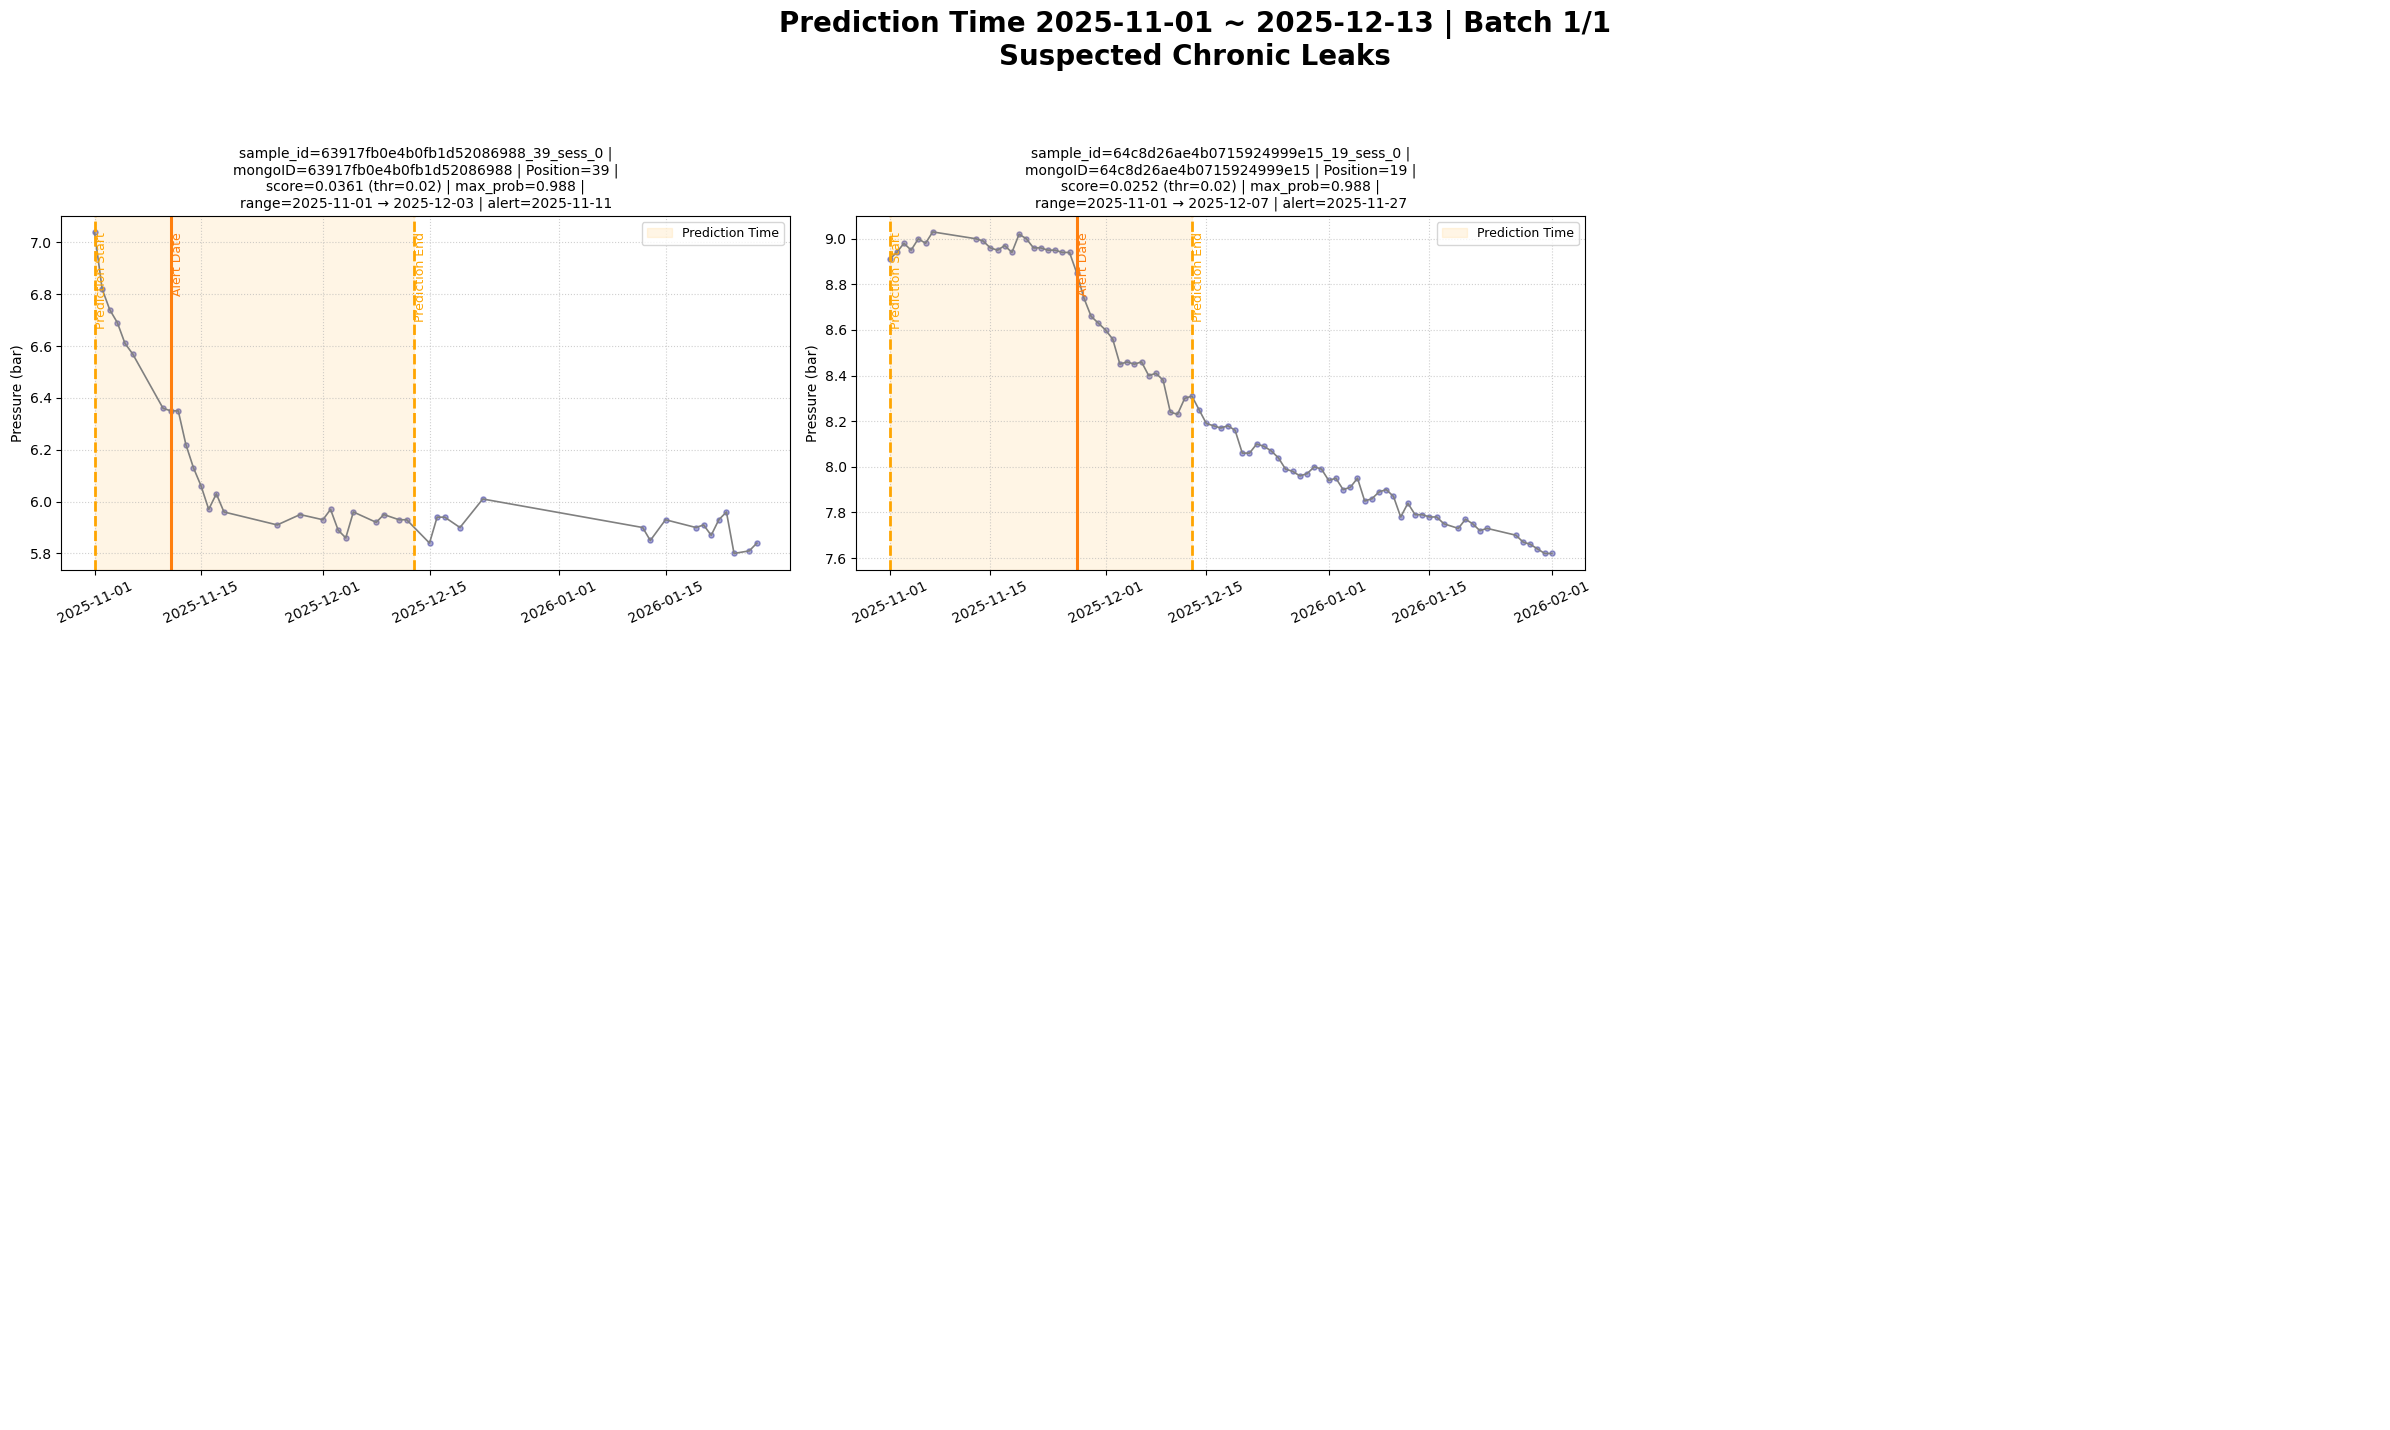

In [76]:
# =======================================================
# Full-history visualization for confirmed leaks (Deployment) - UPDATED
# Changes:
# 1) Use tpms_data_prod_whole_daily (already daily aggregated)
#    Schema: ['mongoID', 'Position', 'date', 'pressure']
# 2) Prediction start vertical line color = GREEN
# 3) sample_id parsing unchanged
# 4) ADDED: Prediction End line + Filled Area + Legend
# 5) ADDED: Text Label for Prediction End
# =======================================================


# -----------------------------
# Safe helpers (avoid max/min shadowing)
# -----------------------------
def _pymax(a, b):
    return a if a >= b else b

def _pymin(a, b):
    return a if a <= b else b

# -----------------------------
# Title helper (wrap + truncate)
# -----------------------------
def _format_title(s: str, width: int = 52, max_lines = None) -> str:
    s = str(s).replace("\n", " ").strip()
    lines = textwrap.wrap(
        s,
        width=width,
        break_long_words=False,
        break_on_hyphens=False,
    )
    if max_lines is None:
        return "\n".join(lines)
    return "\n".join(lines[:max_lines])
    

# -----------------------------
# Config
# -----------------------------
P0 = 0.90
SCORE_THR = 0.020
MIN_PREFIX_WINS = 8

BATCH_SIZE = 9                 # sessions per figure (3 columns -> 3 rows)
ALERT_COLOR = "#FF7F0E"        # orange-red
PRED_COLOR = "orange"            # UPDATED
POINT_SIZE = 14
SCATTER_ALPHA = 0.35
LINE_WIDTH = 1.2

# =======================================================
# 1) Prepare window-level DF from predictions_inf (Spark)
# =======================================================
df_win = predictions_inf

# Ensure prob_leak exists
if "prob_leak" not in df_win.columns:
    if "probability" not in df_win.columns:
        raise ValueError("predictions_inf must contain 'prob_leak' or 'probability'.")
    df_win = df_win.withColumn("prob_leak", vector_to_array(F.col("probability")).getItem(1).cast("double"))

# Ensure window_date timestamp
df_win = df_win.withColumn("window_date_ts", F.to_timestamp(F.col("window_date")))

need_cols = ["sample_id", "window_date_ts", "prob_leak"]
missing = [c for c in need_cols if c not in df_win.columns]
if missing:
    raise ValueError(f"Missing columns in predictions_inf: {missing}. Available: {df_win.columns}")

df_win = df_win.select(*need_cols)

# Excess
df_win = df_win.withColumn("excess", F.greatest(F.col("prob_leak") - F.lit(float(P0)), F.lit(0.0)))

# =======================================================
# 2) Session-level: confirmed leaks (Spark)
# =======================================================
df_sess = (
    df_win.groupBy("sample_id")
    .agg(
        F.count_distinct("window_date_ts").alias("n_windows"),
        F.min("window_date_ts").alias("first_window_date"),
        F.max("window_date_ts").alias("last_window_date"),
        F.max("prob_leak").alias("max_prob"),
        F.avg("excess").alias("score_soft_excess_mean"),
    )
    .withColumn("is_confirmed_leak", (F.col("score_soft_excess_mean") >= F.lit(float(SCORE_THR))).cast("int"))
)

df_confirmed = (
    df_sess.filter(F.col("is_confirmed_leak") == 1)
    .orderBy(F.desc("score_soft_excess_mean"), F.desc("max_prob"))
)

confirmed_count = df_confirmed.count()
print(f"[INFO] Confirmed leaks: {confirmed_count} sessions (P0={P0}, thr={SCORE_THR})")
if confirmed_count == 0:
    raise ValueError("No confirmed leaks found under current parameters.")

pdf_meta = df_confirmed.toPandas()
pdf_meta["sample_id"] = pdf_meta["sample_id"].astype(str)
confirmed_ids = pdf_meta["sample_id"].tolist()

# Meta lookup
meta_map = {}
for _, r in pdf_meta.iterrows():
    sid = str(r["sample_id"])
    meta_map[sid] = {
        "score": float(r["score_soft_excess_mean"]),
        "max_prob": float(r["max_prob"]),
        "n_windows": int(r["n_windows"]),
        "first_window_date": pd.to_datetime(r["first_window_date"]),
        "last_window_date": pd.to_datetime(r["last_window_date"]),
    }

# =======================================================
# 3) Compute Alert Date per sample_id (soft_excess_mean online trigger)
# =======================================================
df_win_small = (
    df_win.filter(F.col("sample_id").isin(confirmed_ids))
    .select(
        F.col("sample_id").cast("string").alias("sample_id"),
        F.col("window_date_ts").alias("window_date"),
        "prob_leak"
    )
    .orderBy("sample_id", "window_date")
)

pdf_pred = df_win_small.toPandas()
pdf_pred["window_date"] = pd.to_datetime(pdf_pred["window_date"])
pdf_pred["prob_leak"] = pdf_pred["prob_leak"].astype(float)
pdf_pred = pdf_pred.sort_values(["sample_id", "window_date"]).reset_index(drop=True)
pdf_pred["excess"] = np.maximum(pdf_pred["prob_leak"].values - P0, 0.0)

trigger_dates = {}
for sid, g in pdf_pred.groupby("sample_id", sort=False):
    g = g.sort_values("window_date")
    ex = g["excess"].to_numpy(dtype=float)
    n = int(ex.size)
    if n <= 0:
        continue

    csum = np.cumsum(ex)
    denom = np.arange(1, n + 1, dtype=float)
    cum_mean = csum / denom

    start_idx = _pymin(n - 1, int(MIN_PREFIX_WINS) - 1)
    if start_idx < 0:
        start_idx = 0

    hit = np.where(cum_mean[start_idx:] >= float(SCORE_THR))[0]
    if hit.size > 0:
        k0 = int(hit[0] + start_idx)
        trigger_dates[sid] = g["window_date"].iloc[k0]
    else:
        trigger_dates[sid] = g["window_date"].iloc[-1]

print("[INFO] Alert dates calculated.")

# =======================================================
# 4) Parse sample_id -> (mongoID, Position)
# =======================================================
def parse_sample_id(s: str):
    parts = str(s).split("_")
    if len(parts) < 2:
        return None, None
    mongo = parts[0]
    pos = parts[1]
    return str(mongo), str(pos)

key_rows = []
for sid in confirmed_ids:
    mongo, pos = parse_sample_id(sid)
    if mongo is None or pos is None:
        continue
    key_rows.append((sid, mongo, pos))

pdf_keys = pd.DataFrame(key_rows, columns=["sample_id", "mongoID", "Position"])
if len(pdf_keys) == 0:
    raise ValueError("Failed to parse sample_id. Check underscore format.")

mongo_ids = pdf_keys["mongoID"].unique().tolist()
pos_list = pdf_keys["Position"].unique().tolist()

print(f"[INFO] History fetch keys: mongoIDs={len(mongo_ids)}, Positions={len(pos_list)}")

# =======================================================
# 5) Fetch daily history from tpms_data_prod_whole_daily (Spark -> pandas)
# Schema: mongoID, Position, date, pressure
# =======================================================
df_hist = (
    tpms_data_prod_whole_daily
    .filter(F.col("mongoID").cast("string").isin(mongo_ids))
    .select(
        F.col("mongoID").cast("string").alias("mongoID"),
        F.col("Position").cast("string").alias("Position"),
        F.col("date").alias("date"),
        F.col("pressure").cast("double").alias("pressure"),
    )
)

pdf_hist = df_hist.toPandas()
pdf_hist["date"] = pd.to_datetime(pdf_hist["date"])
pdf_hist["mongoID"] = pdf_hist["mongoID"].astype(str)
pdf_hist["Position"] = pdf_hist["Position"].astype(str)
pdf_hist["pressure"] = pdf_hist["pressure"].astype(float)

pdf_hist = pdf_hist.sort_values(["mongoID", "Position", "date"]).reset_index(drop=True)
print(f"[INFO] Daily history rows loaded: {len(pdf_hist)}")

# new added tire amount
total_tires_mounted = (
    tpms_cleaned
    .select(F.col("mongoID").cast("string").alias("mongoID"),
            F.col("Position").cast("string").alias("Position"))
    .distinct()
    .count()
)

print(f"[INFO] Total Tire Mounted: {total_tires_mounted}")

# Cache series per (mongoID, Position)
series_cache = {}

def get_series(mongo: str, pos: str):
    key = (mongo, pos)
    if key in series_cache:
        return series_cache[key]
    sub = pdf_hist[(pdf_hist["mongoID"] == mongo) & (pdf_hist["Position"] == pos)][["date", "pressure"]].dropna()
    sub = sub.sort_values("date")
    series_cache[key] = sub
    return sub

# =======================================================
# 6) Plot: 2 columns per row, full-history pressure series
#   - Green line: Prediction Start
#   - Green line: Prediction End
#   - Shaded Area: Prediction Time (Light Green)
#   - Orange-red line: Alert Date
# =======================================================

total_batches = int(np.ceil(len(confirmed_ids) / BATCH_SIZE)) # add batch number
_batch_counter = 0

def plot_batch(batch_sample_ids):
    n = len(batch_sample_ids)
    if n == 0:
        return False

    n_rows, n_cols = 3, 3
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 15))
    axes = np.array(axes).reshape(-1)

    for i, sid in enumerate(batch_sample_ids):
        ax = axes[i]
        sid = str(sid)

        row = pdf_keys[pdf_keys["sample_id"] == sid]
        if row.empty:
            ax.set_axis_off()
            continue

        mongo = row["mongoID"].iloc[0]
        pos = row["Position"].iloc[0]

        sub = get_series(mongo, pos)
        if sub.empty:
            ax.set_axis_off()
            continue

        alert_date = pd.to_datetime(trigger_dates.get(sid, pd.NaT))
        pred_begin = prediction_date_begin
        # Ensure we have the end date available globally or passed in
        pred_end = prediction_date_end 

        # Series
        ax.scatter(sub["date"], sub["pressure"], s=POINT_SIZE, alpha=SCATTER_ALPHA, color ='navy')
        ax.plot(sub["date"], sub["pressure"], linewidth=LINE_WIDTH, color='grey')

        y_top = float(sub["pressure"].max())

        # -------------------------------------------------------
        # UPDATED SECTION: Prediction Time Visualization
        # -------------------------------------------------------
        
        # 1. Fill the area (Shading) and add Label for Legend
        ax.axvspan(pred_begin, pred_end, color = PRED_COLOR, alpha=0.1, label="Prediction Time")
        
        # 2. Prediction Start Line (orange) & Text
        ax.axvline(pred_begin, color="orange", linewidth=2.0, linestyle="--")
        ax.text(
            pred_begin, y_top,
            " Prediction Start",
            rotation=90, va="top", ha="left",
            fontsize=9, color="orange"
        )
        
        # 3. Prediction End Line (orange) & Text
        ax.axvline(pred_end, color="orange", linewidth=2.0, linestyle="--")
        ax.text(
            pred_end, y_top,
            " Prediction End",
            rotation=90, va="top", ha="left",
            fontsize=9, color="orange"
        )
        
        # 4. Legend in Upper Right
        # This will pick up the 'label' from axvspan
        ax.legend(loc="upper right", fontsize=9, frameon=True)

        # -------------------------------------------------------

        # Alert date (ORANGE-RED)
        if pd.notna(alert_date):
            ax.axvline(alert_date, color=ALERT_COLOR, linewidth=2.2)
            ax.text(
                alert_date, y_top,
                " Alert Date",
                rotation=90, va="top", ha="left",
                fontsize=9, color=ALERT_COLOR
            )

        ax.grid(True, linestyle=":", alpha=0.6)
        ax.set_ylabel("Pressure (bar)")
        ax.tick_params(axis="x", rotation=25)

        meta = meta_map.get(sid, None)
        if meta is not None:
            raw_title = (
                f"sample_id={sid} | mongoID={mongo} | Position={pos} | "
                f"score={meta['score']:.4f} (thr={SCORE_THR}) | "
                f"max_prob={meta['max_prob']:.3f} | "
                f"range={meta['first_window_date'].date()} → {meta['last_window_date'].date()} | "
                f"alert={alert_date.date() if pd.notna(alert_date) else 'NA'}"
            )
            ax.set_title(_format_title(raw_title, width=52, max_lines=None), fontsize=10)
        else:
            raw_title = (
                f"sample_id={sid} | mongoID={mongo} | Position={pos} | "
                f"alert={alert_date.date() if pd.notna(alert_date) else 'NA'}"
            )
            ax.set_title(_format_title(raw_title, width=52, max_lines=None), fontsize=10)

    # Remove unused axes
    for j in range(n, n_rows * n_cols):
        axes[j].set_axis_off()

    fig.suptitle(
        f"Prediction Time {prediction_date_begin} ~ {prediction_date_end} | Batch {batch_no}/{total_batches}\n"
        f"Suspected Chronic Leaks",
        fontsize=20, fontweight="bold"
    )

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    plt.show()
    return True

print(f"[INFO] Rendering {len(confirmed_ids)} sessions with full daily history...")

total_batches = math.ceil(len(confirmed_ids) / BATCH_SIZE)
plot_batch._batch_no = 0
for start in range(0, len(confirmed_ids), BATCH_SIZE):
    plot_batch._batch_no += 1
    batch_no = plot_batch._batch_no
    plot_batch(confirmed_ids[start:start + BATCH_SIZE])

### Step 6.2 Detection (Alert) Time

StatementMeta(spkaplarge, 37, 74, Finished, Available, Finished, False)


[INFO] Calculating Data Points Count (Alert Date - Prediction Start)...

Stats Summary for 2 confirmed leaks (Data Points Count):
count     2.000000
mean     15.000000
std       9.899495
min       8.000000
25%      11.500000
50%      15.000000
75%      18.500000
max      22.000000
Name: data_points_diff, dtype: float64
------------------------------
90% Quantile (P90): 20.60 data points
------------------------------


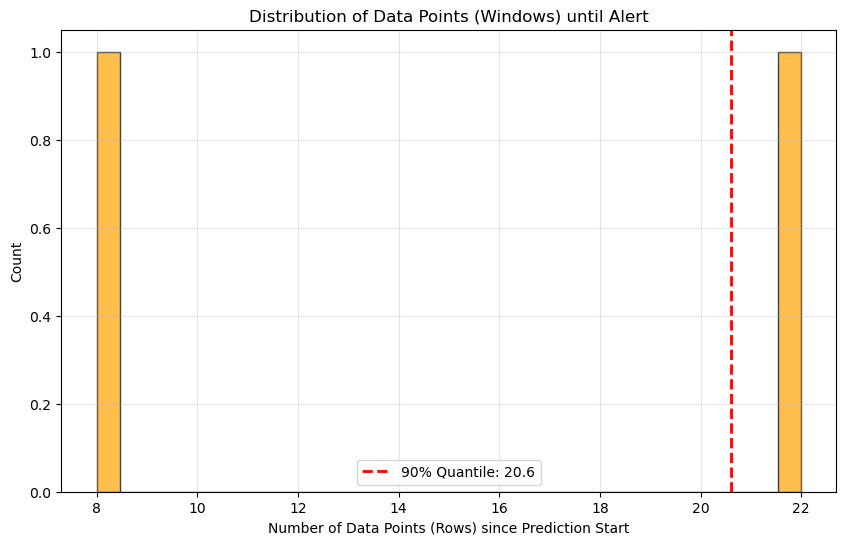

In [73]:
# =======================================================
# 7) Statistics: Alert Data Points vs Prediction Start
# =======================================================

print("\n[INFO] Calculating Data Points Count (Alert Date - Prediction Start)...")

# ensure data format
pred_start_dt = pd.to_datetime(prediction_date_begin)

diff_records = []

# 1. pdf_pred，sort by sample_id and window_date 
#  
pdf_pred_sorted = pdf_pred.sort_values(["sample_id", "window_date"])

for sid, alert_dt in trigger_dates.items():
    if pd.isna(alert_dt):
        continue
        
    # 2. logic
    # how many data points between start date and alert date
    mask = (
        (pdf_pred_sorted["sample_id"] == sid) & 
        (pdf_pred_sorted["window_date"] >= pred_start_dt) & 
        (pdf_pred_sorted["window_date"] <= alert_dt)
    )
    
    # 3. count data point
    data_point_count = mask.sum()
    
    diff_records.append({
        "sample_id": sid,
        "alert_date": alert_dt,
        "prediction_start": pred_start_dt,
        "data_points_diff": data_point_count  # here data point, not date
    })

# DataFrame
df_stats = pd.DataFrame(diff_records)

if not df_stats.empty:

    stats_desc = df_stats["data_points_diff"].describe()
    p90 = df_stats["data_points_diff"].quantile(0.90)  
    
    print(f"\nStats Summary for {len(df_stats)} confirmed leaks (Data Points Count):")
    print(stats_desc)
    print(f"-"*30)
    print(f"90% Quantile (P90): {p90:.2f} data points")
    print(f"-"*30)
 
   
    plt.figure(figsize=(10, 6))
    
    plt.hist(df_stats["data_points_diff"], bins=30, color='orange', edgecolor='black', alpha=0.7)
    
    # 90% quntil
    plt.axvline(p90, color='red', linestyle='--', linewidth=2, label=f'90% Quantile: {p90:.1f}')
    
    plt.title("Distribution of Data Points (Windows) until Alert")
    plt.xlabel("Number of Data Points (Rows) since Prediction Start")
    plt.ylabel("Count")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
else:
    print("[WARN] No valid alert dates found for statistics.")

In [19]:
# THIS NOTEBOOK ENDS HERE

StatementMeta(spkaplarge, 37, 20, Finished, Available, Finished, False)